# Objective Of Feature Engineering Stage

---
The objective of this stage is to transform the raw LendingClub loan dataset into a clean, memory-efficient, and model-ready analytical dataset suitable for credit risk modeling.

This stage focuses on:

- removing data leakage and redundant variables,
- handling missing values and inconsistent data types,
- engineering business-relevant risk features,
- improving computational efficiency,
- and preparing the dataset for machine learning workflows such as Logistic Regression, XGBoost, and LightGBM.

The goal is not only to improve predictive performance, but also to ensure that the final pipeline reflects realistic investor-style loan selection conditions and follows sound risk-modeling practices.

## **1. Initial Setup**

#### **1.1 Memory Check**

In [1]:
import psutil
import gc
gc.collect()

ram = psutil.virtual_memory()

print(f"Total RAM      : {ram.total / (1024**3):.2f} GB")
print(f"Available RAM  : {ram.available / (1024**3):.2f} GB")
print(f"RAM Usage      : {ram.percent}%")

Total RAM      : 7.65 GB
Available RAM  : 1.00 GB
RAM Usage      : 87.0%


#### **1.1 Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import warnings
import os
import sys

warnings.filterwarnings('ignore')
print(f"numpy version : {np.__version__}")
print(f"pandas version : {pd.__version__}")

numpy version : 2.0.2
pandas version : 2.3.3


#### **1.3 Project Paths**

In [3]:
# =========================================================
# Project Paths
# =========================================================


project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

data_path = os.path.join(project_root, 'src', 'data', 'raw', 'accepted_2007_to_2018Q4.csv')

print(f" Project Root : {project_root}")

print(f" \n Data Path : {data_path}")

print(f" \n Path Exists : {os.path.exists(data_path)}")

 Project Root : C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML
 
 Data Path : C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\data\raw\accepted_2007_to_2018Q4.csv
 
 Path Exists : True


In [4]:
PARQUET_DIR = os.path.join(project_root, 'src', 'data', 'processed','parquet_chunks')

FINAL_PARQUET = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks', 'lending_club_1M.parquet')

# =========================================================
# Create Output Directories
# =========================================================

os.makedirs(PARQUET_DIR, exist_ok = True)
os.makedirs(os.path.dirname(FINAL_PARQUET), exist_ok = True)

print(f"Parquet chunks : {PARQUET_DIR}")
print(f"\n Final parquet  : {FINAL_PARQUET}")

Parquet chunks : C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\data\processed\parquet_chunks

 Final parquet  : C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\data\processed\parquet_chunks\lending_club_1M.parquet


## **2. Data Ingestion**

### **2.1 Why Chunking Was Necessary**

The raw dataset contains ~2.26 million rows and 151 features — too large to load directly into memory on this system. The CSV was read in batches of 50,000 rows at a time, keeping memory usage controlled and execution stable.


#### **Why Parquet Was Chosen**

---

After preprocessing and dtype optimization, the dataset was stored in Apache Parquet format instead of CSV.

Parquet was chosen because it:

- loads significantly faster than CSV,
- requires less storage space,
- preserves optimized data types,
- supports efficient columnar storage,
- and reduces repeated preprocessing overhead in future sessions.

This allows future notebooks to load the cleaned dataset directly into memory without repeating expensive ingestion and optimization steps.

### **2.2 Load CSV in Chunks**

In [5]:
# =========================================================
# Sampling Configuration  
# =========================================================

CSV_CHUNK_SIZE = 50_000
SAMPLE_FRAC = 0.75
RANDOM_SEED   = 42


To speed up iterative feature engineering, a development subset was created by sampling 75% of each CSV chunk (chunk size: 50,000 rows, seed: 42). Since sampling happens independently within each chunk, all loan vintages (2007–2018) stay proportionally represented. The full pipeline is still designed to run on 100% of the data in production.

In [6]:
# =========================================================
# Batch Loading Function
# =========================================================

def create_parquet_batch(start_chunk, end_chunk, sample_frac):
    
    sampled_chunks = []

    for i, chunk in enumerate(
        pd.read_csv(
            data_path,
            chunksize=CSV_CHUNK_SIZE,
            low_memory=False
        )
    ):

        # Skip chunks before start
        if i < start_chunk:
            continue

        # Stop at end chunk
        if i >= end_chunk:
            break

        # Random sample from chunk
        sampled_chunk = chunk.sample(
            frac=sample_frac,
            random_state=RANDOM_SEED
        )

        sampled_chunks.append(sampled_chunk)

        print(f"Processed chunk {i} | Shape: {sampled_chunk.shape}")

    # Combine sampled chunks
    batch_df = pd.concat(sampled_chunks, ignore_index=True)

    print("\nBatch creation completed.")
    print(f"Final Batch Shape: {batch_df.shape}")

    return batch_df

In [7]:
batch1 = create_parquet_batch(
    start_chunk=0,
    end_chunk=50,
    sample_frac=SAMPLE_FRAC
)

Processed chunk 0 | Shape: (37500, 151)
Processed chunk 1 | Shape: (37500, 151)
Processed chunk 2 | Shape: (37500, 151)
Processed chunk 3 | Shape: (37500, 151)
Processed chunk 4 | Shape: (37500, 151)
Processed chunk 5 | Shape: (37500, 151)
Processed chunk 6 | Shape: (37500, 151)
Processed chunk 7 | Shape: (37500, 151)
Processed chunk 8 | Shape: (37500, 151)
Processed chunk 9 | Shape: (37500, 151)
Processed chunk 10 | Shape: (37500, 151)
Processed chunk 11 | Shape: (37500, 151)
Processed chunk 12 | Shape: (37500, 151)
Processed chunk 13 | Shape: (37500, 151)
Processed chunk 14 | Shape: (37500, 151)
Processed chunk 15 | Shape: (37500, 151)
Processed chunk 16 | Shape: (37500, 151)
Processed chunk 17 | Shape: (37500, 151)
Processed chunk 18 | Shape: (37500, 151)
Processed chunk 19 | Shape: (37500, 151)
Processed chunk 20 | Shape: (37500, 151)
Processed chunk 21 | Shape: (37500, 151)
Processed chunk 22 | Shape: (37500, 151)
Processed chunk 23 | Shape: (37500, 151)
Processed chunk 24 | Shape

#### **2.3 Dataset Shape & Memory Usage**

In [8]:
batch1.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695526 entries, 0 to 1695525
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 4.4 GB


### **2.4 Drop Leakage Columns**

In [9]:
FINAL_DROP_LIST = [

    # === IDENTIFIERS ===
    'id',
    'member_id',
    'url',
    'policy_code',
     
    # === HIGH CARDINALITY / UNSTRUCTURED TEXT ===
    'title',         # borrower free text — high cardinality, noise
    'zip_code',      # High-cardinality geographic feature; excluded due to privacy/proxy-risk concerns
    
    # === REDUNDANT FEATURES — High correlation ===
    'funded_amnt',
    'funded_amnt_inv',
    'num_sats',
    'num_rev_tl_bal_gt_0',

    # === POST-LOAN PAYMENTS & RECOVERY — Leakage ===
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',

    # === POST-LOAN DATES — Leakage ===
    'last_pymnt_d',
    'next_pymnt_d',
    'last_credit_pull_d',

    # === POST-LOAN FICO — Leakage ===
    'last_fico_range_high',
    'last_fico_range_low',

    # === SETTLEMENT — Leakage ===
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term',

    # === HARDSHIP — Leakage ===
    'hardship_flag',
    'hardship_type',
    'hardship_reason',
    'hardship_status',
    'hardship_start_date',
    'hardship_end_date',
    'payment_plan_start_date',
    'hardship_dpd',
    'hardship_loan_status',
    'hardship_payoff_balance_amount',
    'hardship_amount',
    'orig_projected_additional_accrued_interest',
    'hardship_last_payment_amount',
    'hardship_length',
    'deferral_term',

    # === PAYMENT PLAN — ambiguous / post-loan behavior ===
    'pymnt_plan',

    # === SECONDARY APPLICANT — High missingness,sparse optional fields, ===
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'revol_bal_joint',
    'sec_app_num_rev_accts',
    'sec_app_fico_range_low',
    'sec_app_fico_range_high',
    'sec_app_earliest_cr_line',
    'sec_app_inq_last_6mths',
    'sec_app_mort_acc',
    'sec_app_open_acc',
    'sec_app_revol_util',
    'sec_app_open_act_il',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog',

    # === HIGH MISSING / UNSTRUCTURED ===
    'desc'
]

In [10]:
batch1.drop(columns = FINAL_DROP_LIST, inplace = True, errors = 'ignore')

In [11]:
batch1.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695526 entries, 0 to 1695525
Data columns (total 86 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   loan_amnt                       float64
 1   term                            object 
 2   int_rate                        float64
 3   installment                     float64
 4   grade                           object 
 5   sub_grade                       object 
 6   emp_title                       object 
 7   emp_length                      object 
 8   home_ownership                  object 
 9   annual_inc                      float64
 10  verification_status             object 
 11  issue_d                         object 
 12  loan_status                     object 
 13  purpose                         object 
 14  addr_state                      object 
 15  dti                             float64
 16  delinq_2yrs                     float64
 17  earliest_cr_line           

#### **Why Leakage Columns Were Removed**

---

Several columns in the original dataset contain information that becomes available only after the loan has already been issued or partially repaid.

Examples include:

- recovery amounts,
- settlement information,
- post-loan payment activity,
- hardship program fields,
- and last payment dates.

These variables create target leakage because they reveal information about the future outcome of the loan. Including such features would artificially inflate model performance and produce unrealistic predictions that would not generalize in production environments.

A total of 63 columns were therefore removed to ensure that the final model only uses information that would have been available at the time of investor loan-listing review.


In [12]:
batch1.shape

(1695526, 86)

### **2.5 Convert Date Columns**

In [13]:
num_cols = batch1.select_dtypes(include = ['int64', 'float64']).columns.tolist()

cat_cols = batch1.select_dtypes(include = ['object']).columns.tolist()

print(f" Numerical Columns : {len(num_cols)}")

print(f" Category Columns : {len(cat_cols)}")

 Numerical Columns : 71
 Category Columns : 15


In [14]:
# Identify Date Columns

# earliest_cr_line -> borrower’s earliest recorded credit account opening date.

date_cols = [
            col for col in cat_cols
    
             if any(keyword in col.lower() for keyword in ['_d','date','earliest_cr_line'])
            ]
print(f"Date Columns ({len(date_cols)}) :")

for col in date_cols:
    print(f" - {col}")

Date Columns (2) :
 - issue_d
 - earliest_cr_line


In [15]:
# =========================================================
# Datetime Conversion
# =========================================================

date_cols = ['issue_d', 'earliest_cr_line']

for col in date_cols:
    
    batch1[col] = pd.to_datetime(
        batch1[col], 
        format = '%b-%Y', 
        errors = 'coerce'
    )

### **2.6 Clean emp_length**

In [16]:
#batch1['issue_d']
#batch1['emp_length']
batch1['emp_length'].unique()

array(['2 years', '6 years', '8 years', '7 years', '5 years', '10+ years',
       '< 1 year', '1 year', nan, '4 years', '3 years', '9 years'],
      dtype=object)

In [17]:
def clean_emp_length(col):
    
    col = col.str.replace(r'< 1 year', '0', regex=False)
    
    col = col.str.replace(r'\+ years', '', regex = True)
    
    col = col.str.replace(r' years', '', regex = True)
    
    col = col.str.replace(r' year' ,'', regex = True)

    return pd.to_numeric(col, errors = 'coerce')

In [18]:
batch1['emp_length'] = clean_emp_length(batch1['emp_length'])

In [19]:
batch1['emp_length'].dtype

dtype('float64')

### **2.7 Optimise Dtypes**

In [20]:
# =========================================================
# Dtype Optimization
# =========================================================

import pandas as pd

def optimize_dtypes(df):

    # -----------------------------------------------------
    # Optimize Float Columns | float64 -> float32
    # -----------------------------------------------------
    
    float_cols = df.select_dtypes(include=['float64']).columns

    for col in float_cols:
        
        df[col] = pd.to_numeric(df[col], downcast='float')

    # -----------------------------------------------------
    # Optimize Integer Columns | int64 -> int32/int16/int8
    # -----------------------------------------------------
    
    int_cols = df.select_dtypes(include=['int64']).columns

    for col in int_cols:
        
        df[col] = pd.to_numeric(df[col], downcast='integer')

    # -----------------------------------------------------
    # Convert High-Cardinality Text Columns to String
    # -----------------------------------------------------
    
    high_cardinality_cols = [
        'emp_title'
    ]

    for col in high_cardinality_cols:

        if col in df.columns:
            
            df[col] = df[col].astype('string')

    # -----------------------------------------------------
    # Convert Target Column to Category
    # -----------------------------------------------------
    
    if 'loan_status' in df.columns:
        
        df['loan_status'] = df['loan_status'].astype('category')

    # -----------------------------------------------------
    # Convert Low-Cardinality Columns to Category
    # -----------------------------------------------------
    
    category_cols = [
        'grade',
        'sub_grade',
        'term',
        'home_ownership',
        'verification_status',
        'purpose',
        'addr_state',
        'initial_list_status',
        'application_type',
        'disbursement_method'
        ]

    for col in category_cols:

        if col in df.columns:
            
            df[col] = df[col].astype('category')

    # -----------------------------------------------------
    # Return Optimized DataFrame
    # -----------------------------------------------------
    
    return df

#### **Why Dtype Optimization Was Performed**

---

The raw dataset was initially loaded with default Pandas data types, resulting in high memory consumption.

To improve efficiency:

- object columns were converted to category,
- float64 columns were downcast to float32,

This optimization reduced memory usage substantially while preserving the underlying information. Lower memory usage improves:

- notebook stability,
- preprocessing speed,
- and scalability for downstream feature engineering and modeling tasks.


In [21]:
batch1 = optimize_dtypes(batch1)

In [22]:
batch1.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695526 entries, 0 to 1695525
Data columns (total 86 columns):
 #   Column                          Dtype         
---  ------                          -----         
 0   loan_amnt                       float32       
 1   term                            category      
 2   int_rate                        float32       
 3   installment                     float32       
 4   grade                           category      
 5   sub_grade                       category      
 6   emp_title                       string        
 7   emp_length                      float32       
 8   home_ownership                  category      
 9   annual_inc                      float64       
 10  verification_status             category      
 11  issue_d                         datetime64[ns]
 12  loan_status                     category      
 13  purpose                         category      
 14  addr_state                      category      
 15

In [23]:
batch1['annual_inc'] = batch1['annual_inc'].astype('float32')

### **2.8 Save to Parquet**

In [24]:
# Save Batch as Parquet

batch1.to_parquet(FINAL_PARQUET, index = False)

In [25]:
os.path.exists(FINAL_PARQUET)

True

In [26]:
del batch1

In [27]:
# Python may still keep unused memory references temporarily. gc.collect() forces cleanup.

gc.collect()

0

In [28]:
ram = psutil.virtual_memory()
print(f" Available RAM : {ram.available / 1024**3 :.2f} GB")

 Available RAM : 3.58 GB


#### **Remaining Risks and Limitations**

---

Despite the preprocessing improvements, several limitations and risks still remain in the dataset.

**Sampling Bias**

Although random sampling was performed across all chunks of the dataset, the working dataset is still a subset of the full LendingClub portfolio. Minor distributional differences may still exist, particularly for rare borrower profiles and uncommon loan categories.

**Missing Value Uncertainty**

Some variables contain substantial missingness. In many cases, missing values themselves may carry predictive meaning rather than representing data quality issues. Incorrect imputation strategies could weaken important risk signals.

**Status Label Ambiguity**

Loans with statuses such as:

- Current,
- In Grace Period,
- and Late (16–30 days)

were excluded because their final repayment outcome remains uncertain. While this improves label reliability, it also removes active loans from the modeling population and may slightly alter the observed default distribution.

**Temporal Economic Effects**

The dataset spans multiple economic periods between 2007 and 2018. Borrower behavior, default rates, and LendingClub underwriting standards evolved significantly during this period. As a result, relationships learned from earlier loans may not perfectly generalize to later loans. To reduce temporal leakage and better simulate real-world deployment, model validation should use time-based train/test splits instead of purely random splits.

## **3. Load Processed Data**

### **3.1 Read Parquet**

In [29]:
df = pd.read_parquet(FINAL_PARQUET)
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
0,6000.0,36 months,7.26,185.979996,A,A4,Outreach Coordinator,2.0,MORTGAGE,66000.0,...,5.0,96.199997,40.000000,0.0,0.0,192145.0,29536.0,38000.0,12745.0,Cash
1,12575.0,60 months,18.49,322.690002,E,E2,Financial advisor,6.0,RENT,66000.0,...,3.0,94.699997,100.000000,0.0,0.0,123966.0,110870.0,45900.0,70166.0,Cash
2,16000.0,36 months,5.32,481.839996,A,A1,Marketing manager,8.0,MORTGAGE,96000.0,...,2.0,97.300003,16.700001,0.0,0.0,293017.0,61315.0,43600.0,48119.0,Cash
3,21150.0,60 months,13.67,488.519989,C,C4,Machinist,7.0,RENT,155000.0,...,1.0,100.000000,42.900002,0.0,0.0,382411.0,319507.0,19800.0,324411.0,Cash
4,6000.0,36 months,5.32,180.690002,A,A1,Environmental Engineer,5.0,MORTGAGE,81851.0,...,0.0,100.000000,0.000000,0.0,0.0,126250.0,5734.0,13500.0,13000.0,Cash


In [30]:
#df = pd.read_parquet(FINAL_PARQUET)

for col in ['issue_d', 'earliest_cr_line']:
    
    print(f"{col} | dtype: {df[col].dtype} | sample: {df[col].iloc[0]}")

issue_d | dtype: datetime64[ns] | sample: 2015-12-01 00:00:00
earliest_cr_line | dtype: datetime64[ns] | sample: 1996-04-01 00:00:00


## **4. Target Variable**

In [31]:
df['loan_status'].nunique()

9

In [32]:
loan_status = df['loan_status'].value_counts().sort_values(ascending = False)
loan_status

loan_status
Fully Paid                                             807695
Current                                                658391
Charged Off                                            201600
Late (31-120 days)                                      16116
In Grace Period                                          6351
Late (16-30 days)                                        3245
Does not meet the credit policy. Status:Fully Paid       1496
Does not meet the credit policy. Status:Charged Off       580
Default                                                    25
Name: count, dtype: int64

In [33]:
print(df['issue_d'].max())

2018-12-01 00:00:00


In [34]:
# =========================================================
# STEP 1: How much data does CURRENT approach actually keep
# =========================================================
# This is the last date the LendingClub dataset covers.
SNAPSHOT_DATE = pd.Timestamp('2018-12-31')
PERFORMANCE_WINDOW_MONTHS = 24

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

# Total number of loans issued in each year
raw_counts = df.groupby('issue_year').size()

# A loan only gets a label in your current pipeline if its outcome is
# already fully known — either it finished successfully (Fully Paid)
# or it failed (Charged Off / Default / the older credit-policy versions).
resolved_mask = df['loan_status'].isin([
    'Fully Paid',
    'Charged Off',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
])


#Out of all loans issued each year, how many actually got a usable label?
resolved_counts = df[resolved_mask].groupby('issue_year').size()

# Recent loans are underrepresented
retention_current_approach = (resolved_counts / raw_counts * 100).round(1)

# =========================================================
# How much MORE data would the 24-month-window approach recover?
# =========================================================
# Which rows are currently sitting in "Current" status
is_current = df['loan_status'] == 'Current'

# Calendar-month difference 
# no drift, since issue_d only has month-level precision anyway)
df['_months_since_issue_temp'] = (
    (SNAPSHOT_DATE.year - df['issue_d'].dt.year) * 12 +
    (SNAPSHOT_DATE.month - df['issue_d'].dt.month)
)

# Which rows are OLD ENOUGH that, even though they're still marked "Current,"
# we can trust the label as a non-default
is_mature = df['_months_since_issue_temp'] >= PERFORMANCE_WINDOW_MONTHS

recovered_current = df[is_current & is_mature].groupby('issue_year').size()

# NEW total usable rows per year.
new_resolved_counts = resolved_counts.add(recovered_current, fill_value=0)
retention_new_approach = (new_resolved_counts / raw_counts * 100).round(1)

comparison = pd.DataFrame({
    'total_originated': raw_counts,
    'retained_%_current_approach': retention_current_approach,
    'retained_%_24mo_window': retention_new_approach,
    'rows_recovered': recovered_current.reindex(raw_counts.index, fill_value=0).astype(int)
})

print(comparison)
print(f"\nTotal 'Current' loans in the whole dataset: {is_current.sum():,}")
print(f"Of those, how many are old enough to confidently call non-default: {(is_current & is_mature).sum():,}")

            total_originated  retained_%_current_approach  \
issue_year                                                  
2007.0                   465                        100.0   
2008.0                  1782                        100.0   
2009.0                  3956                        100.0   
2010.0                  9446                        100.0   
2011.0                 16287                        100.0   
2012.0                 40025                        100.0   
2013.0                101073                        100.0   
2014.0                176719                         94.7   
2015.0                315778                         89.2   
2016.0                325867                         67.5   
2017.0                332808                         38.2   
2018.0                371293                         11.4   

            retained_%_24mo_window  rows_recovered  
issue_year                                          
2007.0                       100.0     

**"Test-period (2017–2018) default rates are measured on an immature population, since the dataset ends Dec 2018 — loans from these years have not had sufficient time to reach their full performance window. Reported test AUC/default rates should be interpreted as a lower/partial-information bound, not the loans' true lifetime outcome."**

### **4.1 Create Binary Target**

In [35]:
# =========================================================
#  -TARGET VARIABLE
# =========================================================


DEFAULT_STATUSES = [
    'Charged Off',
    'Default',
    'Late (31-120 days)',
    'Does not meet the credit policy. Status:Charged Off'  
]

NON_DEFAULT_STATUSES = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid'   
]


In [36]:
MATURITY_THRESHOLD_PCT = 1.0

def recover_mature_current_loans(df, snapshot_date, maturity_threshold_pct):
    """
    Some loans are still marked 'Current' only because the dataset was
    captured before their story finished. This function finds the ones
    that have already survived long enough (relative to their own term)
    that we can reasonably treat them as non-default, instead of dropping them.
    """
    months_since_issue = (
        (snapshot_date.year - df['issue_d'].dt.year) * 12 +
        (snapshot_date.month - df['issue_d'].dt.month)
    )

    term_months = df['term'].astype(str).str.extract(r'(\d+)').astype(float)
    term_months = term_months.fillna(term_months.median())

    pct_of_term_elapsed = months_since_issue / term_months.iloc[:, 0]

    is_mature_current = (df['loan_status'] == 'Current') & (pct_of_term_elapsed >= maturity_threshold_pct)
    return is_mature_current

SNAPSHOT_DATE = pd.Timestamp('2018-12-31')
mask_mature_current = recover_mature_current_loans(df, SNAPSHOT_DATE, MATURITY_THRESHOLD_PCT)
print("Mature 'Current' loans recovered:", mask_mature_current.sum())

mask_keep = df['loan_status'].isin(DEFAULT_STATUSES + NON_DEFAULT_STATUSES) | mask_mature_current
df = df[mask_keep].copy()
del mask_keep, mask_mature_current
import gc; gc.collect()

df['target'] = df['loan_status'].isin(DEFAULT_STATUSES).astype('int8')
print(df['target'].value_counts())

Mature 'Current' loans recovered: 55
target
0    809246
1    218321
Name: count, dtype: int64


In [37]:
val_df = df[df['issue_year'] == 2017]
test_df = df[df['issue_year'] == 2018]

val_recovered = (val_df['loan_status'] == 'Current')  # by definition, only mature ones survived the filter
print(f"Recovered ('Current', now labeled non-default) rows in val: {val_recovered.sum()}")
print(f"As % of val: {val_recovered.sum() / len(val_df) * 100:.2f}%")
print(f"\nVal default rate: {val_df['target'].mean():.4f}")
print(f"Test default rate: {test_df['target'].mean():.4f}")

Recovered ('Current', now labeled non-default) rows in val: 0
As % of val: 0.00%

Val default rate: 0.2660
Test default rate: 0.2521


### **4.2 Business Definition of Default**

#### What We Are Predicting

We are predicting whether a borrower will default before approving their loan. The model uses only features available at the time of loan issuance, to avoid data leakage. Training is only possible on loans where the outcome is known — either fully resolved, or reasonably inferred using a fixed performance window (below).

---

#### Basel III Alignment

The target is defined as serious delinquency/default-like risk — useful for investor screening, while acknowledging `Late (31-120 days)` is broader than strict regulatory default. It separates clearly successful loans from loans with severe repayment distress or charge-off.

---

| Loan Status | Label | Reason |
|---|---|---|
| `Fully Paid` | **0** | Loan completed successfully |
| `Charged Off` | **1** | Written off after 120+ days non-payment |
| `Default` | **1** | Meets regulatory default definition |
| `Late (31-120 days)` | **1** | Meets 90-day Basel III threshold |
| `Current` (fully matured) | **0** | Completed 100% of term — see below |
| `Current` (not fully matured) | Excluded | Outcome not yet resolved — see below |
| `In Grace Period` | Excluded | See below |
| `Late (16-30 days)` | Excluded | See below |
| `...Status:Charged Off` | **1** | Same as Charged Off, older policy |
| `...Status:Fully Paid` | **0** | Same as Fully Paid, older policy |

---

#### Handling `Current` Loans: Maturity Threshold

Excluding all `Current` loans biases the data toward recent vintages, since those loans simply haven't had time to resolve yet.

**First attempt — 67% of term:** A `Current` loan was initially trusted as non-default once it survived 67% of its own term (e.g. 24 of 36 months), on the assumption that a loan likely to default early would have already shown signs of it. This recovered a large number of loans — close to 100,000 for 2016 alone.

**Why it was changed:** When used in modeling, this threshold caused validation performance to exceed training performance — a sign the model was underfitting rather than genuinely generalizing well. This suggested the recovered "partially matured" loans weren't a reliable enough proxy for true non-default outcomes, and were introducing label noise rather than removing it.

**Final decision — 100% of term:** The threshold was raised so that only loans that have **fully completed their term** are labeled non-default. This is a stricter, more conservative definition: a loan is only trusted as "paid off successfully" once it has actually run its full course, not just survived long enough to seem safe.

**Remaining caveat:** 2017–2018 loans can't reach full term completion before the dataset's Dec-2018 cutoff, so the temporal test split is still evaluated on an immature population — a dataset limitation, not fixable by the threshold itself.

---

#### Excluded Statuses and Why

- **`Current` (not fully matured):** Right-censored — outcome unknown. Excluding avoids label noise.
- **`In Grace Period`:** The borrower is 1–15 days late. This falls within the standard industry grace window and isn't considered credit distress. The outcome is too uncertain to assign a reliable label.
- **`Late (16-30 days)`:** The borrower has missed one installment. At this early stage, it's unclear whether the loan will recover or continue toward default — self-curing is common, but not guaranteed. Labeling these loans as default overstates the risk; labeling them as non-default understates it. Excluding them keeps both classes clean and unambiguous.

In [38]:
leak_candidates = ['months_since_issue', 'term_months', 'pct_of_term', '_months_since_issue_temp']
print([c for c in leak_candidates if c in df.columns])

['_months_since_issue_temp']


In [39]:
df = df.drop(columns=['_months_since_issue_temp'], errors='ignore')

### **4.3 Class Distribution**

In [40]:
target_pct = df['target'].value_counts(normalize = True) * 100

print(f" 0(Non- Default) : {target_pct[0] :.2f}% ")

print(f" 1( Default) : {target_pct[1] :.2f}% ")

 0(Non- Default) : 78.75% 
 1( Default) : 21.25% 


In [41]:
# Verify Mapping
df[['loan_status','target']].drop_duplicates().sort_values('target',ascending = False)

,loan_status,target
9,Charged Off,1
287,Late (31-120 days),1
9276,Default,1
1237552,Does not meet the credit policy. Status:Charge...,1
0,Fully Paid,0
416,Current,0
1237508,Does not meet the credit policy. Status:Fully ...,0


In [42]:
# drop df['loan_status] -> leakage
df.drop(columns = ['loan_status'], inplace = True)

## **5. Informative Missingness Flags**

In [43]:
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    
    'missing_pct' : (df.isnull().sum() / len(df) * 100)
    
}).sort_values('missing_pct', ascending = False)

missing = missing[missing['missing_count'] > 0]

print(f"Columns with missing values : {len(missing)}")

print(missing.to_string())

Columns with missing values : 68
                                missing_count  missing_pct
mths_since_last_record                 852277    82.941258
mths_since_recent_bc_dlq               783756    76.272983
mths_since_last_major_derog            757076    73.676558
mths_since_recent_revol_delinq         683861    66.551475
il_util                                665688    64.782929
mths_since_rcnt_il                     620323    60.368132
all_util                               609086    59.274578
open_act_il                            609044    59.270490
open_acc_6m                            609044    59.270490
open_rv_12m                            609044    59.270490
total_bal_il                           609044    59.270490
open_rv_24m                            609044    59.270490
max_bal_bc                             609044    59.270490
inq_fi                                 609044    59.270490
total_cu_tl                            609044    59.270490
open_il_24m            

### **5.1 Create Binary Flags**

In [44]:
# =========================================================
#  — INFORMATIVE MISSINGNESS FLAGS
# =========================================================
#  Rule : NaN does NOT mean data quality issue here
#        NaN means the borrower never had that negative event
# =========================================================


df['ever_delinquent']        = df['mths_since_last_delinq'].notna().astype('int8')
df['has_public_record']     = df['mths_since_last_record'].notna().astype('int8')
df['has_bc_delinquency']    = df['mths_since_recent_bc_dlq'].notna().astype('int8')
df['has_major_derog']       = df['mths_since_last_major_derog'].notna().astype('int8')
df['has_installment_accts'] = df['il_util'].notna().astype('int8')
df['has_rcnt_il']           = df['mths_since_rcnt_il'].notna().astype('int8')
df['has_revol_delinq']      = df['mths_since_recent_revol_delinq'].notna().astype('int8')
df['has_bankcard']          = df['bc_util'].notna().astype('int8')

### **5.2 Verify Flags**

In [45]:
flag_map = {
    'ever_delinquent'       : 'mths_since_last_delinq',
    'has_public_record'     : 'mths_since_last_record',
    'has_bc_delinquency'    : 'mths_since_recent_bc_dlq',
    'has_major_derog'       : 'mths_since_last_major_derog',
    'has_installment_accts' : 'il_util',
    'has_rcnt_il'           : 'mths_since_rcnt_il',
    'has_revol_delinq'      : 'mths_since_recent_revol_delinq',
    'has_bankcard'          : 'bc_util',
}

print(f" {'Flag' : <30} {'% Flagged' : >10}  {'Source Column' :<35}  {'Missing' : >10}")

print("-" * 90)

for flag, source in flag_map.items():
    
    pct_flagged = df[flag].mean() * 100
    
    pct_missing = df[source].isna().mean() * 100
    
    print(f"{flag:<30} {pct_flagged:>9.1f}%  {source:<35} {pct_missing:>9.1f}%")
    

 Flag                            % Flagged  Source Column                           Missing
------------------------------------------------------------------------------------------
ever_delinquent                     49.6%  mths_since_last_delinq                   50.4%
has_public_record                   17.1%  mths_since_last_record                   82.9%
has_bc_delinquency                  23.7%  mths_since_recent_bc_dlq                 76.3%
has_major_derog                     26.3%  mths_since_last_major_derog              73.7%
has_installment_accts               35.2%  il_util                                  64.8%
has_rcnt_il                         39.6%  mths_since_rcnt_il                       60.4%
has_revol_delinq                    33.4%  mths_since_recent_revol_delinq           66.6%
has_bankcard                        95.3%  bc_util                                   4.7%


In [46]:
df.shape

(1027567, 95)

In [47]:
df.head()
#df.info(memory_usage='deep')

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,issue_year,target,ever_delinquent,has_public_record,has_bc_delinquency,has_major_derog,has_installment_accts,has_rcnt_il,has_revol_delinq,has_bankcard
0,6000.0,36 months,7.26,185.979996,A,A4,Outreach Coordinator,2.0,MORTGAGE,66000.0,...,2015.0,0,1,0,0,0,0,0,1,1
2,16000.0,36 months,5.32,481.839996,A,A1,Marketing manager,8.0,MORTGAGE,96000.0,...,2015.0,0,1,0,0,1,1,1,0,1
4,6000.0,36 months,5.32,180.690002,A,A1,Environmental Engineer,5.0,MORTGAGE,81851.0,...,2015.0,0,0,0,0,0,0,0,0,1
5,17000.0,36 months,7.89,531.859985,A,A5,Project Manager,10.0,RENT,78415.0,...,2015.0,0,0,0,0,0,0,0,0,1
6,3000.0,36 months,13.18,101.349998,C,C3,Sales and Recruiting Coordinator,0.0,RENT,45000.0,...,2015.0,0,0,0,0,0,1,1,0,1


## **6. Data Quality Fixes**

### **6.1 annual_inc — Impossible Values**

In [48]:
print(df[df['annual_inc'] < 100][['loan_amnt', 'annual_inc', 'grade', 'target']].head(10))

print(f"\nCount below 100 : {(df['annual_inc'] < 100).sum()}")

        loan_amnt  annual_inc grade  target
20876     20000.0         0.0     D       0
301275    14000.0         0.0     D       0
302625    40000.0         0.0     C       1
303759    28000.0         0.0     B       0
304695    21000.0         0.0     B       0
306256    16000.0         0.0     C       1
307112     7800.0         0.0     C       0
308257    30000.0         0.0     D       1
313310    15000.0         0.0     B       0
317335    13000.0         0.0     E       0

Count below 100 : 306


In [49]:
df[(df['annual_inc'] > 3600) & (df['annual_inc'] < 5000)][
['loan_amnt', 'annual_inc', 'grade', 'target']].sort_values('annual_inc')

,loan_amnt,annual_inc,grade,target
367632,3850.0,3700.000000,C,0
1188280,12000.0,3755.959961,D,0
1170380,4525.0,3775.199951,C,1
664192,14000.0,3900.000000,E,0
826578,1500.0,4000.000000,E,1
1039711,4500.0,4000.000000,B,0
912408,1300.0,4000.000000,C,0
468452,16000.0,4000.000000,B,0
1262102,5350.0,4000.000000,D,0
1256724,1200.0,4000.000000,C,0


#### Note on Data Quality Fixes
---
These issues were discovered during feature engineering
when `df.describe()` revealed impossible values in derived
features (`pti_ratio`, `loan_to_income`, `dti(-1.0)`).

### **6.2 dti — Sentinel and Impossible Values**

In [50]:
print(f"dti < 0 : {(df['dti'] < 0).sum()}")

print(f"dti == -1 : {(df['dti'] == -1).sum()}")

print(f"dti null : {df['dti'].isna().sum()}")

# Look at the actual rows
df[df['dti'] < 0][['loan_amnt', 'annual_inc', 'dti', 'grade', 'target']].head(10)

dti < 0 : 1
dti == -1 : 1
dti null : 301


,loan_amnt,annual_inc,dti,grade,target
770100,15000.0,94000.0,-1.0,B,0


In [51]:
suspicious_mask = (
    (df['annual_inc'] < 5000) &
    (df['loan_amnt'] / df['annual_inc'] > 3)
)
print(f"Suspicious rows  : {suspicious_mask.sum()}")
print(f" % of total      : {suspicious_mask.mean() * 100:.3f}%")
print(f" Default rate (suspicious)   : {df.loc[suspicious_mask, 'target'].mean():.2%}")
print(f"\nSample of suspicious rows:")
print(
    df.loc[suspicious_mask, ['loan_amnt', 'annual_inc', 'grade', 'target']]
    .head(20)
    .to_string()
)

Suspicious rows  : 408
 % of total      : 0.040%
 Default rate (suspicious)   : 25.74%

Sample of suspicious rows:
        loan_amnt   annual_inc grade  target
11161      6550.0  1770.000000     D       0
20876     20000.0     0.000000     D       0
300457     5750.0  1200.000000     C       0
301275    14000.0     0.000000     D       0
302625    40000.0     0.000000     C       1
302925    12000.0  2000.000000     F       0
303759    28000.0     0.000000     B       0
304695    21000.0     0.000000     B       0
306256    16000.0     0.000000     C       1
306898    17600.0  1288.780029     B       0
307112     7800.0     0.000000     C       0
308257    30000.0     0.000000     D       1
313310    15000.0     0.000000     B       0
317335    13000.0     0.000000     E       0
318701    35000.0     0.000000     C       1
319276    35000.0     0.000000     G       0
325035     7000.0     0.000000     D       0
329144    37000.0  3600.000000     B       0
330647     4500.0     0.000000

### Problem

---

During analysis, a small group of borrowers showed:

- Extremely low annual income (`annual_inc < 5000`)
- Very large loan amounts compared to their income

These combinations are financially unrealistic for approved personal loans and likely indicate:

- data entry mistakes
- incorrect income reporting
- placeholder values
- unverifiable borrower information

---

### Why Use 5,000 as the Income Threshold?

An annual income below `$5,000` means the borrower earns less than about `$417/month`.

At this income level:

- Monthly loan repayments would consume a very large portion of income
- Such applications would normally be considered very high risk
- Some of these borrowers were still assigned good loan grades (`A`, `B`, `C`), which is inconsistent with normal lending practices

This strongly suggests that some of these income values are unreliable.

---

### Why Use 3x as the Loan-to-Income Threshold?

In personal lending, loan amounts are usually much smaller than annual income.

Typical ranges:

- Standard personal loans: around `0.5x – 1x` annual income
- High-risk cases: sometimes up to `2x`
- Ratios above `3x` are extremely unusual for unsecured personal loans

For example:

A borrower earning `$4,177/year` receiving a `$35,000` loan would have repayments far beyond what their income could realistically support.

This is highly unlikely in a real lending environment.

---

### Why Not Remove All Low-Income Borrowers?

Low income alone does not automatically mean the data is invalid.

Some borrowers may still legitimately have:

- part-time income
- temporary unemployment
- alternative income sources
- joint applications

Removing all low-income borrowers could incorrectly remove valid records.

---

### Business-Driven Rule

Instead of using only a hard income cutoff, a combined financial plausibility rule was applied.

A borrower was marked as suspicious only when BOTH conditions were true:

1. `annual_inc < 5000`
2. `loan_amnt / annual_inc > 3`

This identifies borrowers who:

- report extremely low income
- while also receiving a disproportionately large loan

Such combinations are highly unrealistic in real-world lending scenarios.

In [52]:
# =========================================================
# DATA QUALITY FIXES 
# =========================================================

# Fix 1 — annual_inc zeros and impossibly low values
df['annual_inc'] = df['annual_inc'].replace(0, np.nan)

df.loc[
    (df['annual_inc'] < 5000) &
    (df['loan_amnt'] / df['annual_inc'] > 3),
    'annual_inc'] = np.nan

# Fix 2 — dti sentinel value
df['dti'] = df['dti'].replace(-1, np.nan)

print(f"annual_inc nulls : {df['annual_inc'].isna().sum()}")

print(f"dti        nulls : {df['dti'].isna().sum()}")

annual_inc nulls : 411
dti        nulls : 302


In [53]:
print(f"\nannual_inc missing after cleaning : {df['annual_inc'].isna().sum():,}")
print(f"dti missing after cleaning        : {df['dti'].isna().sum():,}")


annual_inc missing after cleaning : 411
dti missing after cleaning        : 302


**Annual income quality check:** Applicants with extremely low reported annual income (< $5,000) combined with a loan-to-income ratio greater than 3 were considered implausible records. These values were treated as missing (NaN) rather than removed, allowing subsequent imputation while preserving the observations. Only 473 loans (0.04%) were affected, indicating that the rule corrected a very small number of anomalous records without materially altering the dataset.

## **7. Feature Engineering**

In [54]:
# =========================================================
# PRE-ENGINEERING DATA QUALITY CHECK
# =========================================================
print(f"annual_inc zeros  : {(df['annual_inc'] == 0).sum()}")
print(f"annual_inc nulls  : {df['annual_inc'].isna().sum()}")
print(f"tot_hi_cred_lim zeros : {(df['tot_hi_cred_lim'] == 0).sum()}")
print(f"installment zeros : {(df['installment'] == 0).sum()}")

annual_inc zeros  : 0
annual_inc nulls  : 411
tot_hi_cred_lim zeros : 14
installment zeros : 0


In [55]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

def engineer_features(df):

    # --- FICO midpoint ---
    # Two separate columns in raw data -> one clean score
    df['fico_score'] = (
        (df['fico_range_low'] + df['fico_range_high']) / 2
    ).astype('float32')


    # --- Payment-to-income ratio ---
    # What fraction of monthly income goes to this loan repayment
    # Higher = more financial stress = higher default risk
    df['pti_ratio'] = (
        df['installment'] / (df['annual_inc'] / 12)
    ).astype('float32')


    # --- Loan-to-income ratio ---
    # How large is this loan relative to annual income
    # Higher = borrower taking on more than they can handle
    df['loan_to_income'] = (
        df['loan_amnt'] / df['annual_inc']
    ).astype('float32')


    # --- Overall credit utilization ---
    # +1 avoids division by zero for borrowers with no credit limit recorded
    df['overall_util'] = (
        df['tot_cur_bal'] / (df['tot_hi_cred_lim'] + 1)
    ).astype('float32')


    # --- Credit history age ---
    # Older history usually indicates more stable borrowers
    df['credit_age_yrs'] = (
        (df['issue_d'] - df['earliest_cr_line']).dt.days / 365
    ).astype('float32')


    # --- Loan issue year ---
    # Captures economic cycle effects
    df['issue_year'] = (
        df['issue_d'].dt.year
    ).astype('Int16')
    
    return df

In [56]:
df =  engineer_features(df)

In [57]:
# =========================================================
# POST-ENGINEERING INFINITY CHECK
# =========================================================
num_inf = np.isinf(
    df.select_dtypes(include=[np.number])
).sum().sum()

if num_inf > 0:
    print(f"WARNING : {num_inf} infinite values found — replacing with NaN")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
else:
    print(f"Infinite values : 0 ")

Infinite values : 0 


In [58]:
print(f"issue_d NaT count        : {df['issue_d'].isna().sum()}")
print(f"earliest_cr_line NaT count: {df['earliest_cr_line'].isna().sum()}")

issue_d NaT count        : 0
earliest_cr_line NaT count: 24


In [59]:
df = engineer_features(df)

### **7.1 Drop Replaced Source Columns**

In [60]:
df.drop(
    columns=['fico_range_low', 'fico_range_high','earliest_cr_line','installment'],
    inplace=True
)
print(df.shape)

(1027567, 96)


In [61]:
ram = psutil.virtual_memory()
print(f"Available RAM      : {ram.available / 1024**3:.2f} GB")

Available RAM      : 2.18 GB


In [62]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [63]:
df.describe()

,loan_amnt,int_rate,emp_length,annual_inc,issue_d,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,...,has_major_derog,has_installment_accts,has_rcnt_il,has_revol_delinq,has_bankcard,fico_score,pti_ratio,loan_to_income,overall_util,credit_age_yrs
count,"1,027,567.00","1,027,567.00","967,350.00","1,027,156.00",1027567,"1,027,265.00","1,027,543.00","1,027,543.00","509,978.00","175,290.00",...,"1,027,567.00","1,027,567.00","1,027,567.00","1,027,567.00","1,027,567.00","1,027,567.00","1,027,156.00","1,027,156.00","974,850.00","1,027,543.00"
mean,"14,441.84",13.28,5.96,"76,305.89",2015-06-13 21:57:01.290485504,18.30,0.32,0.66,34.31,70.50,...,0.26,0.35,0.40,0.33,0.95,698.08,0.08,0.22,0.72,16.25
min,500.00,5.31,0.00,948.00,2007-06-01 00:00:00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,612.00,0.00,0.00,0.00,0.50
25%,"8,000.00",9.75,2.00,"45,760.00",2014-07-01 00:00:00,11.79,0.00,0.00,16.00,53.00,...,0.00,0.00,0.00,0.00,1.00,672.00,0.05,0.12,0.60,11.18
50%,"12,000.00",12.79,6.00,"65,000.00",2015-08-01 00:00:00,17.63,0.00,0.00,31.00,72.00,...,0.00,0.00,0.00,0.00,1.00,692.00,0.07,0.20,0.77,14.76
75%,"20,000.00",16.02,10.00,"90,000.00",2016-07-01 00:00:00,24.08,0.00,1.00,50.00,90.00,...,1.00,1.00,1.00,1.00,1.00,712.00,0.11,0.29,0.88,20.01
max,"40,000.00",30.99,10.00,"9,522,972.00",2018-12-01 00:00:00,999.00,30.00,33.00,226.00,129.00,...,1.00,1.00,1.00,1.00,1.00,847.50,3.24,8.00,14.55,83.31
std,"8,732.70",4.79,3.69,"70,677.95",NaN,11.32,0.88,0.96,21.93,26.76,...,0.44,0.48,0.49,0.47,0.21,31.81,0.05,0.13,0.20,7.51


### **7.2 emp_title — Feature Engineering**

In [64]:
print(f" emp_title nulls : {df['emp_title'].isna().sum()}")

print(f" unique_values : {df['emp_title'].nunique()}")


 emp_title nulls : 65915
 unique_values : 304778


In [65]:
print(df['emp_title'].value_counts().head(10))

emp_title
Teacher             16229
Manager             14842
Owner                8057
Registered Nurse     6800
RN                   6471
Supervisor           6362
Driver               5789
Sales                5709
Project Manager      4873
Office Manager       4160
Name: count, dtype: Int64


In [66]:
# How much of the data do top N titles cover?
value_counts = df['emp_title'].value_counts()

for n in [100, 500, 1000, 5000]:
    
    coverage = value_counts.head(n).sum() / df['emp_title'].count() * 100
    
    print(f"Top {n:>5} titles cover : {coverage:.1f}% of non-null rows")

print(f"\nSingle occurrence titles : {(value_counts == 1).sum():,}")

print(f"% of unique values       : {(value_counts == 1).sum() / len(value_counts) * 100:.1f}%")

Top   100 titles cover : 21.3% of non-null rows
Top   500 titles cover : 34.6% of non-null rows
Top  1000 titles cover : 40.5% of non-null rows
Top  5000 titles cover : 54.0% of non-null rows

Single occurrence titles : 244,986
% of unique values       : 80.4%


### `emp_title` Feature Engineering

emp_title  is a high-cardinality text feature containing:

- inconsistent capitalization
- spelling variations
- trailing spaces
- abbreviations
- rare job titles
- noisy free-text entries
  
To avoid creating thousands of sparse categories, the employment titles were first normalized and then grouped into broader occupation-based categories using a rule-based text mapping approach.

However, this transformation did not improve model performance. Instead of adding clearer signal, the grouped categories introduced additional noise and did not produce a meaningful gain in AUC.

As a result, this feature engineering step was not retained as a beneficial transformation for the final model.

In [67]:
# =========================================================
# DROP RAW EMPLOYMENT TITLE 
# =========================================================

df.drop(columns = ['emp_title'], inplace = True)


### **8. Temporal Train / Validation / Test Split**

#### Why Random Split Was Avoided

Random splitting assumes all observations are independent and follow the same distribution over time. That assumption doesn't hold here, because:
- Borrower behavior changes over time
- Economic conditions shift across years
- LendingClub's underwriting standards evolved between 2007–2018

A random split would leak future borrower behavior into training, producing overly optimistic results that wouldn't hold up in real-world deployment.

---

#### Why a Temporal Split Was Used

A temporal split better simulates production behavior:
- The model trains only on historical loans
- Validation and test sets contain future, unseen borrowers
- Performance degradation across time reflects real concept drift, not a modeling flaw

This gives a more realistic estimate of how the model would perform on future loan applications.

---
#### Temporal Drift Observation

Default rates rise sharply in later years, confirming substantial drift in borrower quality, economic conditions, lending behavior, and underwriting strategy over time. As a result, the model faces a genuinely harder prediction environment in the validation and test periods than it did during training.

**Expected model behavior:** Since the training period has a lower default rate than later years, the model may underestimate risk on newer borrowers, and evaluation metrics may decline from validation to test. This reflects a real distribution shift, not model failure.

---
### 8.4 Known Limitation — 2018 Underrepresentation

2018 loans are underrepresented in the dataset because very few of them have had time to reach full term completion by the dataset's Dec-2018 cutoff. Under the maturity rule from Section 4, a `Current` loan is only labeled non-default once it has completed 100% of its term — so most 2018 loans (and many 2017 loans with longer terms) are still excluded as not yet mature, rather than confirmed as either default or non-default. As a result, the test set contains fewer 2018 loans than expected and skews more toward 2017 lending behavior.


In [68]:
df['issue_year'].value_counts().sort_index()

issue_year
2007       465
2008      1782
2009      3956
2010      9446
2011     16287
2012     40025
2013    101072
2014    167584
2015    282650
2016    223330
2017    133152
2018     47818
Name: count, dtype: Int64

### **8.1 Default Rate by Year — Drift Analysis**

In [69]:
yearly_default =(
    df.groupby('issue_year')['target'].mean().mul(100).round(2)
)
print(yearly_default)

issue_year
2007   26.88
2008   20.31
2009   13.75
2010   13.94
2011   14.99
2012   16.25
2013   15.56
2014   18.50
2015   20.57
2016   24.49
2017   26.60
2018   25.21
Name: target, dtype: float64


### **8.2 Split Design**

In [70]:
# =========================================================
# Train : 2007-2015  — model learns from historical data
# Val   : 2016       — hyperparameter tuning
# Test  : 2017-2018  — final evaluation on unseen future data
# =========================================================

train_df = df[df['issue_year'] <=2015].copy()

val_df = df[df['issue_year'] ==2016].copy()

test_df = df[df['issue_year'] >=2017].copy()

# Drop issue_d 
train_df.drop(columns = ['issue_d'], inplace = True)

val_df.drop(columns = ['issue_d'], inplace = True)

test_df.drop(columns = ['issue_d'], inplace = True)

In [71]:
# Verify
print(f"{'Split':<10} {'Rows':>10} {'Default Rate':>15} {'% of Total':>12}")

print("-" * 50)

print(f"{'Train':<10} {len(train_df):>10,} {train_df['target'].mean():>14.2%} {len(train_df)/len(df):>11.2%}")

print(f"{'Val':<10} {len(val_df):>10,} {val_df['target'].mean():>14.2%} {len(val_df)/len(df):>11.2%}")

print(f"{'Test':<10} {len(test_df):>10,} {test_df['target'].mean():>14.2%} {len(test_df)/len(df):>11.2%}")

print("-" * 50)

print(f"{'Total':<10} {len(df):>10,}")

Split            Rows    Default Rate   % of Total
--------------------------------------------------
Train         623,267         18.64%      60.65%
Val           223,330         24.49%      21.73%
Test          180,970         26.23%      17.61%
--------------------------------------------------
Total       1,027,567


### **8.3 Separate Features and Target**

In [72]:
#Train
X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

# Validation
X_val   = val_df.drop(columns=['target'])
y_val   = val_df['target']

# Test
X_test  = test_df.drop(columns=['target'])
y_test  = test_df['target']

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (623267, 93)
X_val   : (223330, 93)
X_test  : (180970, 93)


### **8.4 Memory Cleanup**

In [73]:
# Then delete all dataframes, no longer needed
del df, train_df, val_df, test_df

# Force Python to release memory held by deleted objects
import gc
gc.collect()

ram = psutil.virtual_memory()
print(f"Available RAM : {ram.available / 1024**3:.2f} GB")

Available RAM : 2.21 GB


In [74]:
X_train.memory_usage(deep=True).sum() / 1024**2

np.float64(193.1886968612671)

## **9. Outlier Treatment**

In [75]:
numeric_cols = X_train.select_dtypes(
    include=['float32', 'float64', 'int16', 'int32', 'int64']
).columns

binary_flags = ['ever_delinquent', 'has_public_record', 'has_bc_delinquency',
                
                'has_major_derog', 'has_installment_accts', 'has_rcnt_il',
                
                'has_revol_delinq', 'has_bankcard']

numeric_cols = [col for col in numeric_cols if col not in binary_flags]

desc = X_train[numeric_cols].describe().loc[['min','max','mean','std']].T
desc = desc.sort_values('max', ascending=False)

print(desc.to_string())

                                    min          max       mean        std
total_rev_hi_lim                   0.00 9,999,999.00  31,605.54  34,673.61
tot_hi_cred_lim                    0.00 9,999,999.00 168,667.81 171,751.55
annual_inc                     1,896.00 9,500,000.00  74,606.68  67,319.86
tot_cur_bal                        0.00 8,000,078.00 137,561.42 153,291.62
total_bal_ex_mort                  0.00 2,688,920.00  48,274.38  45,786.68
revol_bal                          0.00 2,560,703.00  16,553.88  21,856.20
total_il_high_credit_limit         0.00 1,241,783.00  40,034.55  41,524.06
avg_cur_bal                        0.00   958,084.00  13,204.66  15,932.18
total_bal_il                       0.00   878,459.00  35,642.13  42,384.35
total_bc_limit                     0.00   760,000.00  20,756.59  20,676.61
bc_open_to_buy                     0.00   559,912.00   8,987.57  14,095.59
tot_coll_amt                       0.00   496,651.00     218.18   1,956.14
max_bal_bc               

In [76]:
print((X_train['tot_hi_cred_lim'] == 9_999_999).sum())

print((X_train['total_rev_hi_lim'] == 9_999_999).sum())

2
1


### **9.1 Sentinel Value Treatment**

In [77]:
# Replace sentinel values with NaN before winsorization
# 9,999,999 is a system placeholder — not a real credit limit

# train
X_train['tot_hi_cred_lim'] = X_train['tot_hi_cred_lim'].replace(9_999_999, np.nan)

X_train['total_rev_hi_lim'] = X_train['total_rev_hi_lim'].replace(9_999_999, np.nan)

# val
X_val['tot_hi_cred_lim'] = X_val['tot_hi_cred_lim'].replace(9_999_999, np.nan)

X_val['total_rev_hi_lim'] = X_val['total_rev_hi_lim'].replace(9_999_999, np.nan)

#test
X_test['tot_hi_cred_lim'] = X_test['tot_hi_cred_lim'].replace(9_999_999, np.nan)

X_test['total_rev_hi_lim'] = X_test['total_rev_hi_lim'].replace(9_999_999, np.nan)

print((X_train['tot_hi_cred_lim'] == 9_999_999).sum())

print((X_train['total_rev_hi_lim'] == 9_999_999).sum())

0
0


In [78]:
X_train['dti'] = X_train['dti'].replace(999, np.nan)

X_val['dti']   = X_val['dti'].replace(999, np.nan)

X_test['dti']  = X_test['dti'].replace(999, np.nan)

In [79]:
print(X_train['dti'].value_counts().sort_index(ascending=False).head(15))

dti
380.53    1
137.40    1
125.25    1
120.66    1
100.09    1
89.83     1
83.64     1
83.40     1
71.40     1
69.35     1
68.30     1
67.50     1
64.99     1
61.21     1
60.08     1
Name: count, dtype: int64


In [80]:
print(X_train['dti'].quantile([0.95, 0.99, 0.999]))

print(f"dti > 65  count : {(X_train['dti'] > 65).sum()}")

print(f"dti > 100 count : {(X_train['dti'] > 100).sum()}")

print(f"dti == 999 count: {(X_train['dti'] == 999).sum()}")

0.95   32.47
0.99   37.30
1.00   39.70
Name: dti, dtype: float32
dti > 65  count : 12
dti > 100 count : 5
dti == 999 count: 0


### **9.2 Winsorisation — Financial Balance Columns**

In [81]:
X_train['dti'] = X_train['dti'].mask(X_train['dti'] > 65, np.nan)

X_val['dti']   = X_val['dti'].mask(X_val['dti'] > 65, np.nan)

X_test['dti']  = X_test['dti'].mask(X_test['dti'] > 65, np.nan)

In [82]:
# =========================================================
# WINSORISATION COLUMNS
# =========================================================
# These features contain heavily right-skewed financial values.
# A small number of borrowers have extremely large balances
# or credit limits that can destabilize model learning.
#
# Instead of removing rows, extreme values are capped at the
# upper percentile to reduce outlier influence while preserving
# borrower information.
# =========================================================

winsor_cols = [
    'annual_inc',
    'tot_cur_bal',
    'total_bal_ex_mort',
    'revol_bal',
    'total_il_high_credit_limit',
    'avg_cur_bal',
    'total_bal_il',
    'total_bc_limit',
    'bc_open_to_buy',
    'max_bal_bc',
    'tot_coll_amt',
    'delinq_amnt',
    'tot_hi_cred_lim',
    'total_rev_hi_lim',
]

In [83]:
# =========================================================
# APPLY WINSORISATION
# =========================================================
# Upper caps are learned only from training data to prevent
# data leakage from validation and test sets.
#The same caps are then applied consistently across all splits.
# =========================================================

caps = {}

# Learn 99th percentile caps from training data
for col in winsor_cols:
   
    if col in X_train.columns:
        
        upper = X_train[col].quantile(0.99)
        
        caps[col] = upper

# Apply to all splits
for col, upper in caps.items():
    
    X_train[col] = X_train[col].clip( upper = upper)
    
    X_val[col]   = X_val[col].clip(upper=upper)
    
    X_test[col]  = X_test[col].clip(upper=upper)


In [84]:
# =========================================================
# SKEWNESS CHECK — VISUAL + DECISION
# =========================================================
import matplotlib.pyplot as plt

LOG_TRANSFORM_THRESHOLD = 1.0


def plot_and_transform(df_train, df_val, df_test, cols,
                       threshold=LOG_TRANSFORM_THRESHOLD):

    """
    For each feature:
    1. Calculate skewness after winsorization.
    2. Simulate log1p transformation.
    3. Compare skewness before vs after.
    4. Apply log1p only if:
         - |skew| > threshold
         - log1p reduces absolute skewness
         - feature contains no values < 0
    5. Plot both distributions.
    """

    results = []

    for col in cols:

        if col not in df_train.columns:
            continue

        train_values = df_train[col].dropna()

        if train_values.empty:
            continue

        # -----------------------------
        # Original skewness
        # -----------------------------
        skew_winsor = train_values.skew()

        # -----------------------------
        # Check if log1p is possible
        # -----------------------------
        can_log = train_values.min() >= 0

        if can_log:
            log_values = np.log1p(train_values)
            skew_log = log_values.skew()
        else:
            log_values = train_values.copy()
            skew_log = np.nan

        # -----------------------------
        # Decide whether to transform
        # -----------------------------
        apply_log = (
            can_log
            and abs(skew_winsor) > threshold
            and abs(skew_log) < abs(skew_winsor)
        )

        decision = "log1p applied" if apply_log else "No transform"

        # -----------------------------
        # Plot
        # -----------------------------
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        fig.suptitle(col, fontsize=13, fontweight='bold')

        ax1.hist(
            train_values,
            bins=50,
            color="steelblue",
            edgecolor="white",
            linewidth=0.3
        )

        ax1.set_title(
            f"After Winsorization\nSkew = {skew_winsor:.2f}"
        )
        ax1.set_ylabel("Count")
        ax1.grid(alpha=0.3)

        ax2.hist(
            log_values,
            bins=50,
            color="seagreen",
            edgecolor="white",
            linewidth=0.3
        )

        if can_log:
            ax2.set_title(
                f"After log1p\nSkew = {skew_log:.2f}"
            )
        else:
            ax2.set_title(
                "log1p not applicable\n(contains negative values)"
            )

        ax2.set_ylabel("Count")
        ax2.grid(alpha=0.3)

        fig.text(
            0.5,
            0.02,
            f"Decision: {decision}",
            ha="center",
            fontsize=10,
            color="green" if apply_log else "gray"
        )

        plt.tight_layout()
        plt.show()

        # -----------------------------
        # Apply transformation
        # -----------------------------
        if apply_log:

            df_train[col] = np.log1p(df_train[col])
            df_val[col] = np.log1p(df_val[col])
            df_test[col] = np.log1p(df_test[col])

        # -----------------------------
        # Store summary
        # -----------------------------
        results.append({
            "column": col,
            "skew_winsor": round(skew_winsor, 2),
            "skew_log": round(skew_log, 2) if can_log else np.nan,
            "action": decision
        })

    # =====================================================
    # Final Summary
    # =====================================================

    summary = pd.DataFrame(results).sort_values(
        by="skew_winsor",
        key=lambda x: np.abs(x),
        ascending=False
    )

    print("\n" + "=" * 70)
    print("TRANSFORMATION SUMMARY")
    print("=" * 70)
    print(summary.to_string(index=False))

    return summary

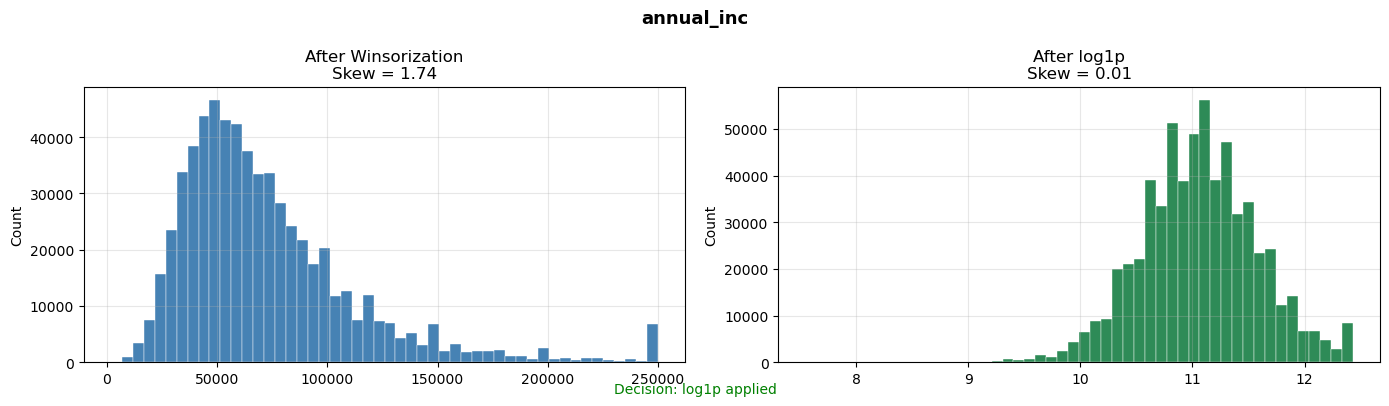

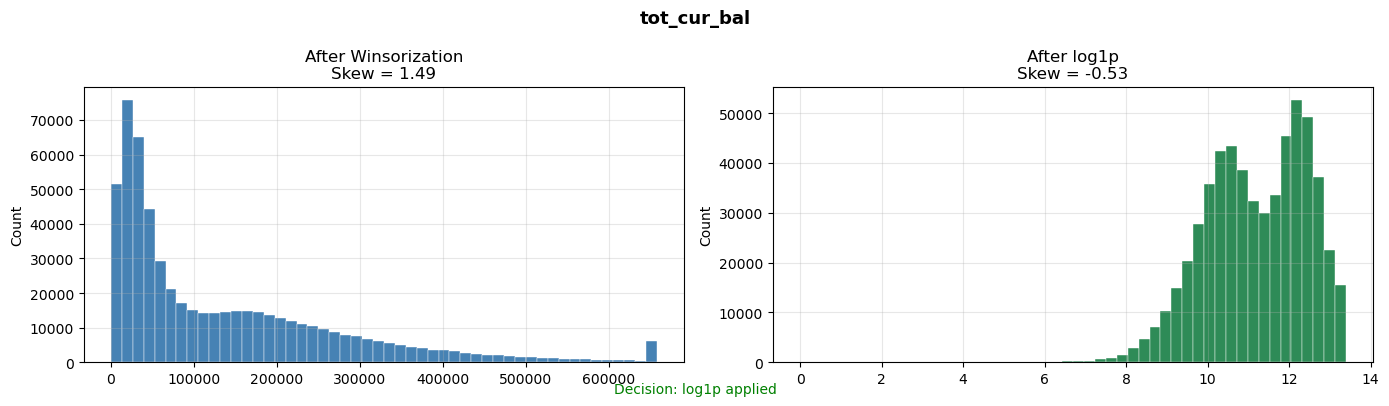

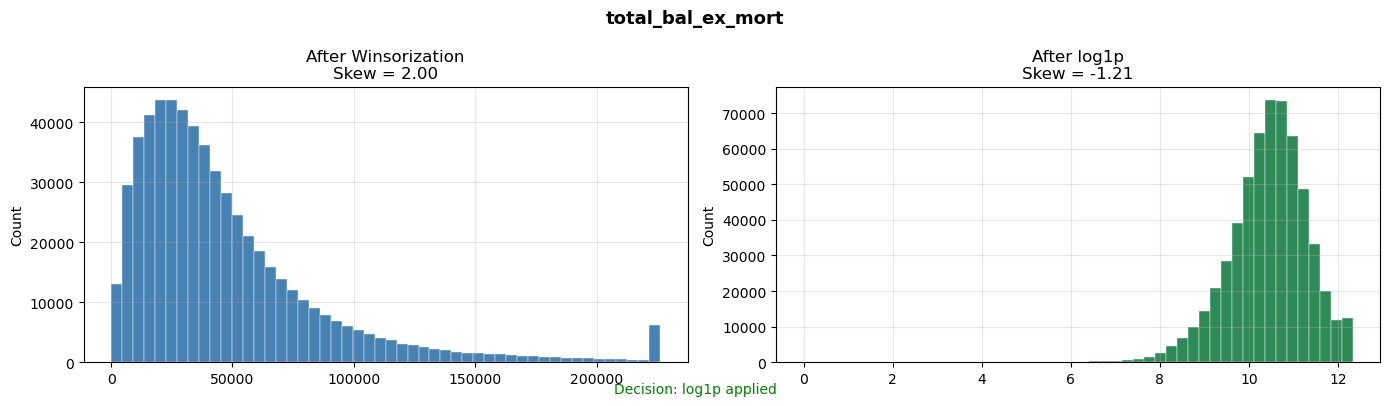

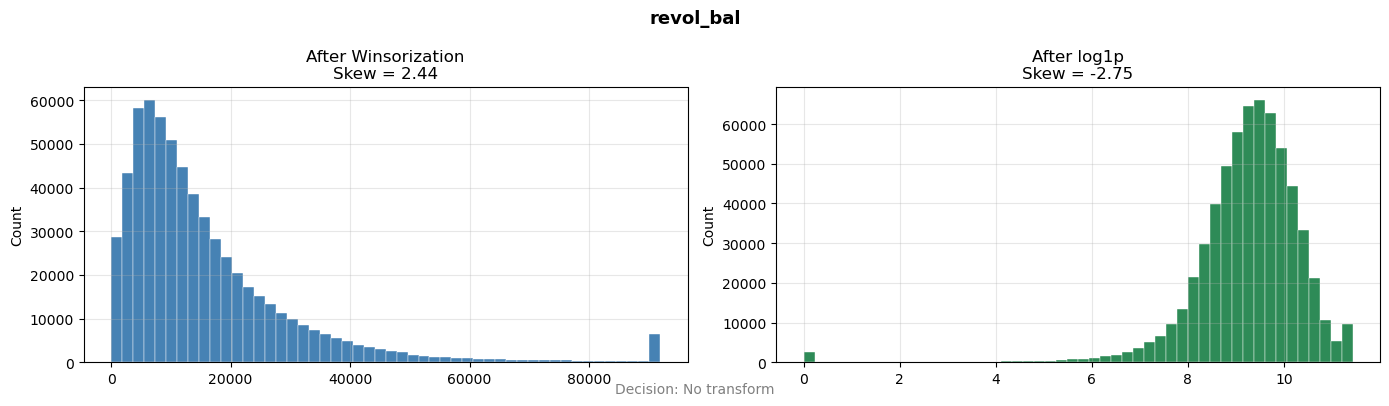

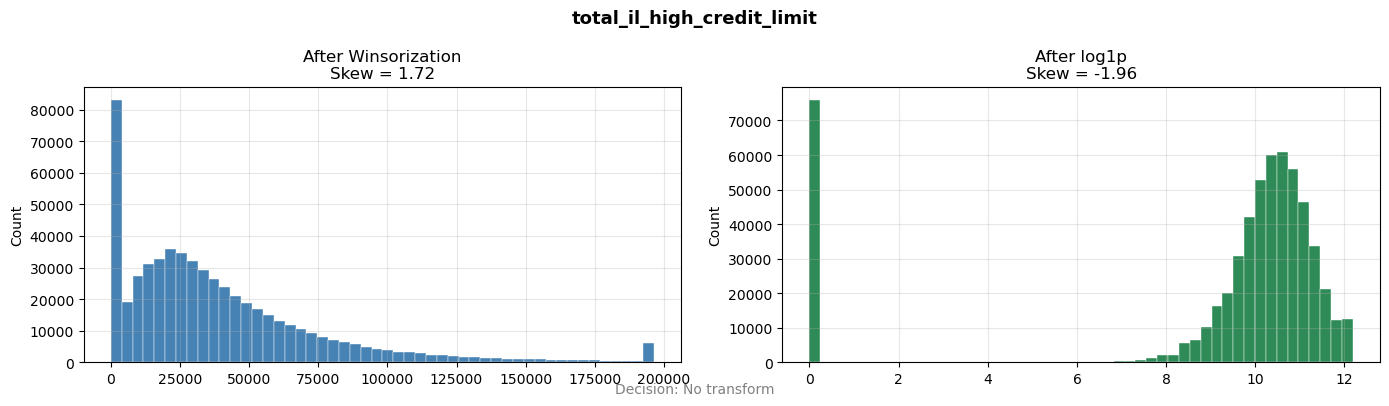

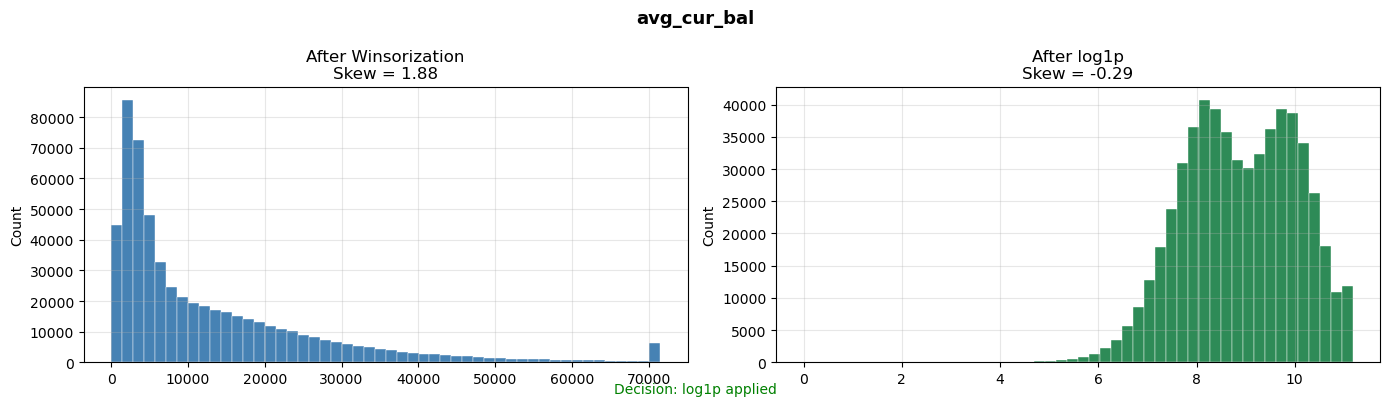

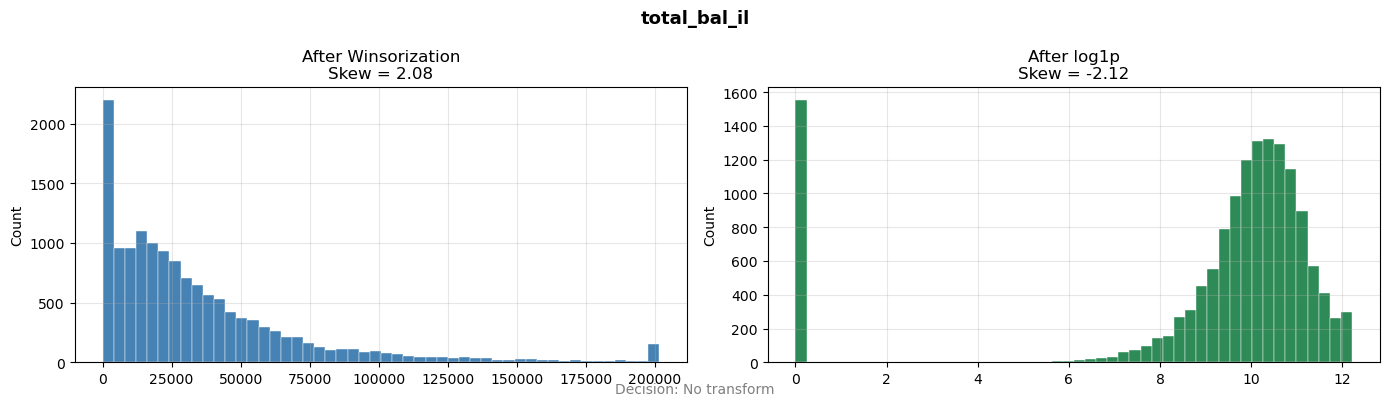

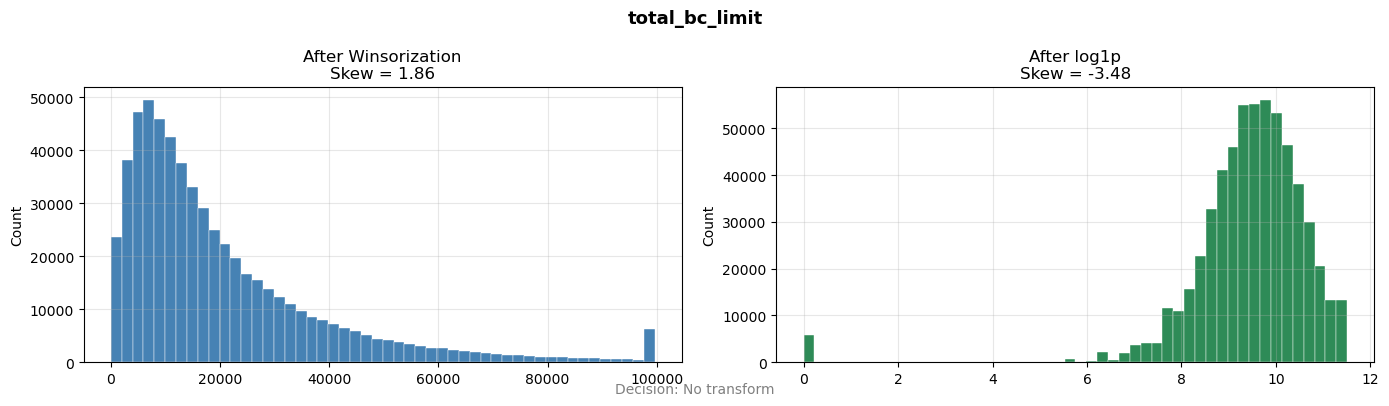

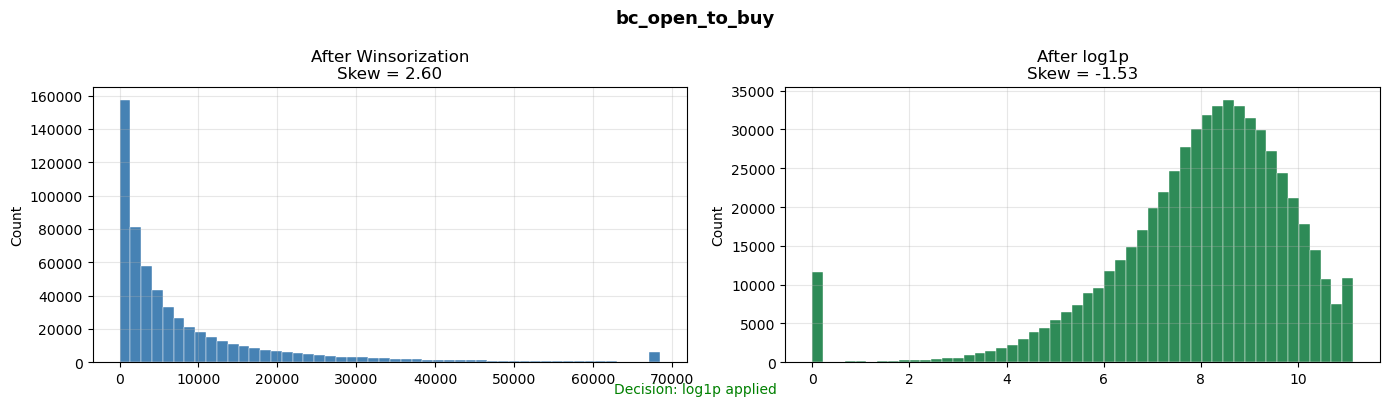

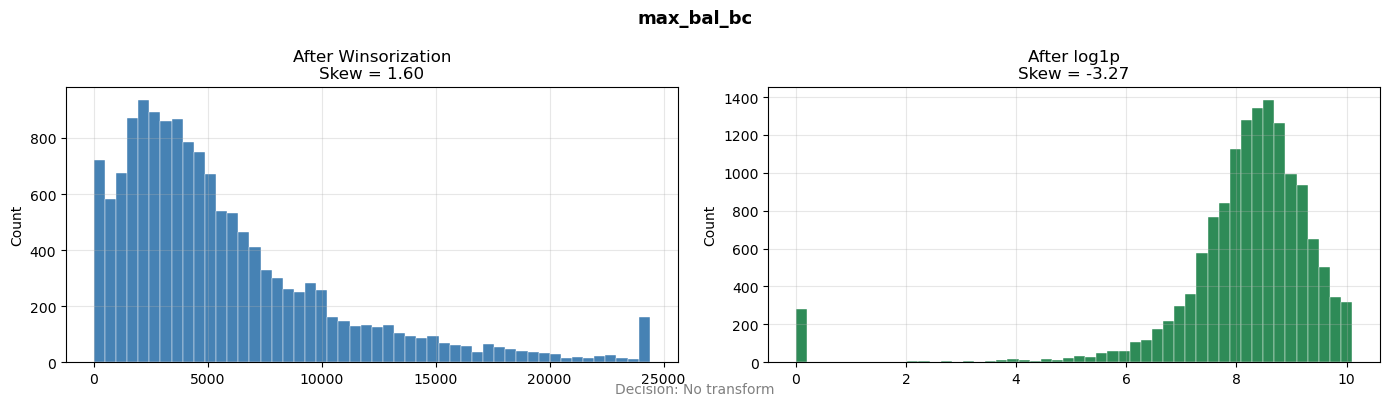

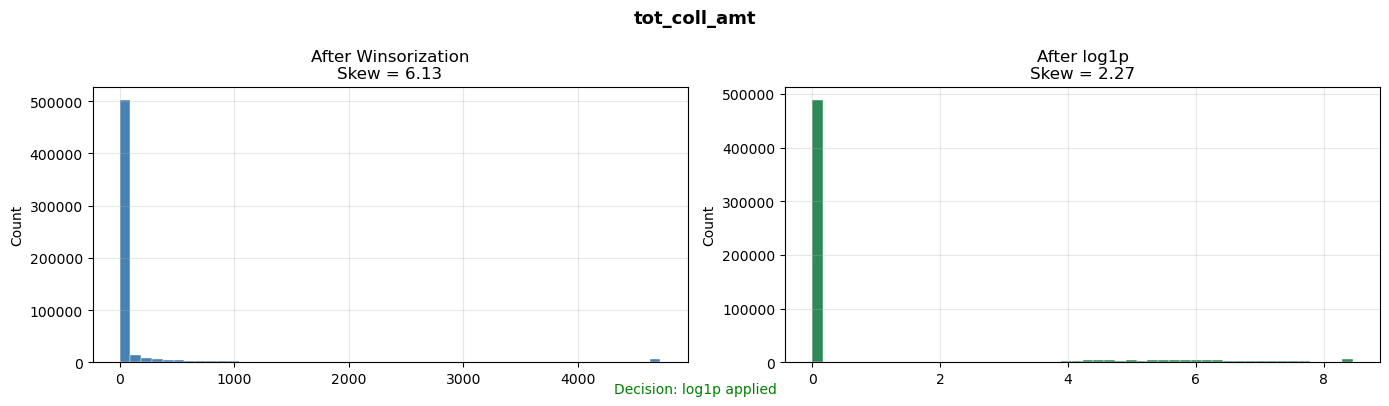

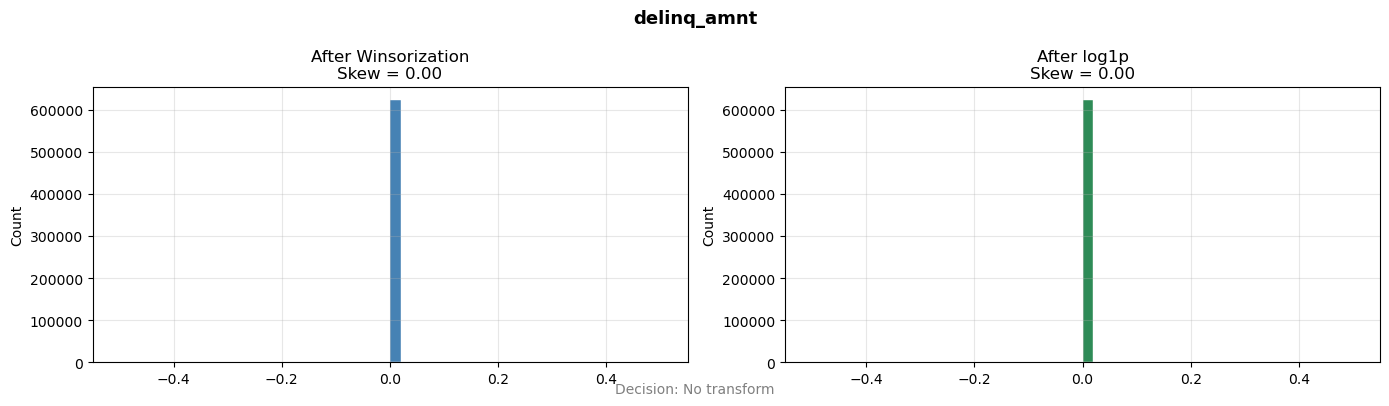

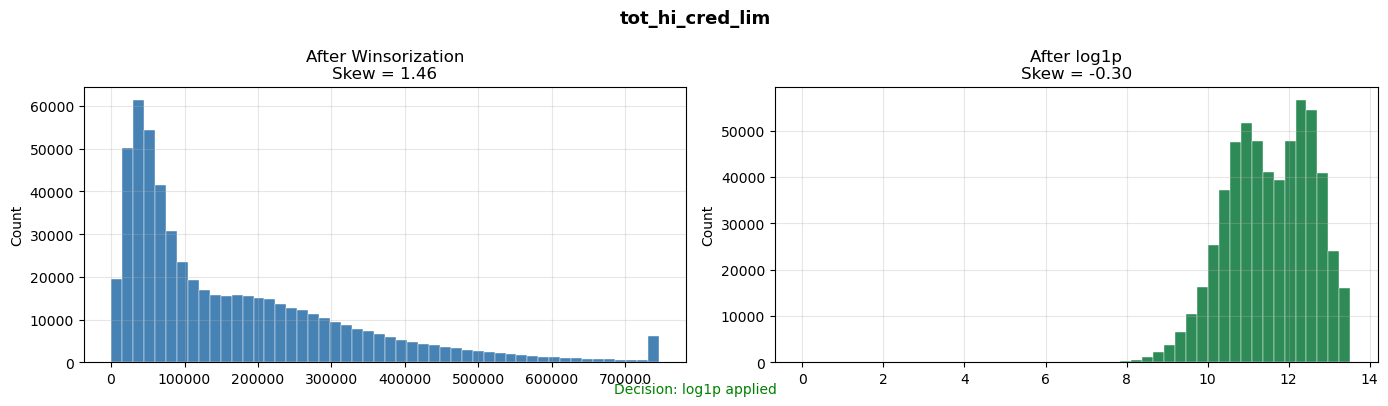

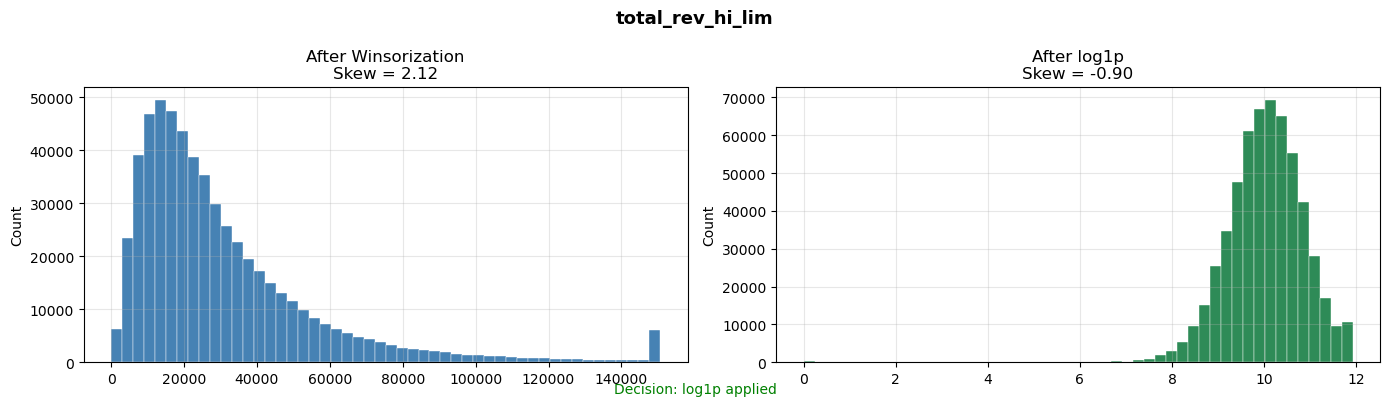


TRANSFORMATION SUMMARY
                    column  skew_winsor  skew_log        action
              tot_coll_amt         6.13      2.27 log1p applied
            bc_open_to_buy         2.60     -1.53 log1p applied
                 revol_bal         2.44     -2.75  No transform
          total_rev_hi_lim         2.12     -0.90 log1p applied
              total_bal_il         2.08     -2.12  No transform
         total_bal_ex_mort         2.00     -1.21 log1p applied
               avg_cur_bal         1.88     -0.29 log1p applied
            total_bc_limit         1.86     -3.48  No transform
                annual_inc         1.74      0.01 log1p applied
total_il_high_credit_limit         1.72     -1.96  No transform
                max_bal_bc         1.60     -3.27  No transform
               tot_cur_bal         1.49     -0.53 log1p applied
           tot_hi_cred_lim         1.46     -0.30 log1p applied
               delinq_amnt         0.00      0.00  No transform


In [85]:
skew_report = plot_and_transform(
    df_train = X_train,
    df_val   = X_val,
    df_test  = X_test,
    cols     = winsor_cols,
    threshold = LOG_TRANSFORM_THRESHOLD
)

> **Note on "No transform" decisions:**
> For some columns, log1p over-corrects — producing negative skewness
> larger in magnitude than the original right skew. In these cases,
> winsorization alone is the better treatment. The function correctly
> detected this using the condition: apply log1p only if
> abs(skew_log) < abs(skew_winsor).

### **9.3 Business Rule Caps — Utilisation Columns**

In [86]:
# =========================================================
# BUSINESS RULE CAPS
# =========================================================
# These variables have natural financial limits.
# Extremely large values usually indicate data quality issues
# or unrealistic borrower information.
#
# Fixed caps are applied using domain knowledge rather than
# percentile-based winsorisation.
# =========================================================

business_caps = {

    'revol_util': 150,
    # Revolving utilization above 150% is likely reporting error.

    'bc_util': 150,
    # Bankcard utilization above 150% is unrealistic.

    'il_util': 150,
    # Installment utilization above 150% is unreliable.

    'all_util': 150,
    # Overall utilization above 150% indicates abnormal reporting.
}

In [87]:
# =========================================================
# APPLY BUSINESS CAPS
# =========================================================

for col, cap in business_caps.items():

    X_train[col] = X_train[col].clip(upper=cap)

    X_val[col] = X_val[col].clip(upper=cap)

    X_test[col] = X_test[col].clip(upper=cap)


# =========================================================
# VERIFY CAPS
# =========================================================

print(f"\n{'Column':<15} {'Cap':>8} {'Train Max':>12} {'Val Max':>12} {'Test Max':>12}")

print("-" * 65)

for col, cap in business_caps.items():

    print(
        f"{col:<15} "
        f"{cap:>8} "
        f"{X_train[col].max():>12.2f} "
        f"{X_val[col].max():>12.2f} "
        f"{X_test[col].max():>12.2f}"
    )


Column               Cap    Train Max      Val Max     Test Max
-----------------------------------------------------------------
revol_util           150       150.00       150.00       150.00
bc_util              150       150.00       150.00       150.00
il_util              150       150.00       150.00       150.00
all_util             150       150.00       150.00       150.00


In [88]:
print(f"X_train dti actual max : {X_train['dti'].max():.2f}")

print(f"X_val   dti actual max : {X_val['dti'].max():.2f}")

print(f"X_test  dti actual max : {X_test['dti'].max():.2f}")

X_train dti actual max : 64.99
X_val   dti actual max : 64.77
X_test  dti actual max : 64.99


## **10. Imputation**

### Why Imputation Comes After Split

---

Imputation learns a statistic from data — the median or mode.
If fitted on the full dataset before splitting:
- Future borrower patterns influence the training median
- Test set information leaks into training statistics
- Model evaluation becomes overly optimistic

Correct approach:
- Fit imputer on X_train only
- Apply same statistics to X_val and X_test
- Simulates production — only historical patterns are known

### **10.1 Missing Value Summary — After Split**

In [89]:
# =========================================================
# MISSING VALUE SUMMARY
# Performed on X_train after split
# =========================================================

missing = pd.DataFrame({
    
    'train_nulls' : X_train.isnull().sum(),
    
    'train_pct'   : (X_train.isnull().sum() / len(X_train) * 100).round(2),
    
    'val_nulls'   : X_val.isnull().sum(),
    
    'test_nulls'  : X_test.isnull().sum(),
    
}).sort_values('train_pct', ascending = False)


missing = missing[missing['train_nulls'] > 0]

print(f"Columns with missing values : {len(missing)}")

print(missing.to_string())

Columns with missing values : 70
                                train_nulls  train_pct  val_nulls  test_nulls
il_util                              610866      98.01      28825       25997
mths_since_rcnt_il                   609399      97.77       5705        5219
inq_fi                               609006      97.71         38           0
total_cu_tl                          609006      97.71         38           0
open_acc_6m                          609006      97.71         38           0
open_rv_24m                          609006      97.71         38           0
open_rv_12m                          609006      97.71         38           0
total_bal_il                         609006      97.71         38           0
open_il_24m                          609006      97.71         38           0
open_act_il                          609006      97.71         38           0
open_il_12m                          609006      97.71         38           0
all_util                       

### **10.2 Missing Analysis**

In [90]:
# =========================================================
# STRUCTURAL MISSINGNESS ANALYSIS
# Missingness by issue year
# =========================================================

structural_cols = [
    'all_util',
    'open_rv_12m',
    'open_rv_24m',
    'open_il_12m',
    'open_il_24m',
    'open_acc_6m',
    'open_act_il',
    'total_bal_il',
    'total_cu_tl',
    'inq_fi',
    'inq_last_12m',
    'mths_since_rcnt_il',
    'max_bal_bc',
    'il_util'
]

for col in structural_cols:

    temp = (
        
        X_train.groupby(X_train['issue_year'])[col]
        
        .apply(lambda x: x.isna().mean() * 100)
        
        .round(2)
    )

    print(f"\n{'='*60}")
    
    print(f"{col} — Missing % by Year")
    
    print(f"{'='*60}")

    summary = pd.DataFrame({ 'missing_pct': temp })

    print(summary)


all_util — Missing % by Year
            missing_pct
issue_year             
2007             100.00
2008             100.00
2009             100.00
2010             100.00
2011             100.00
2012             100.00
2013             100.00
2014             100.00
2015              94.95

open_rv_12m — Missing % by Year
            missing_pct
issue_year             
2007             100.00
2008             100.00
2009             100.00
2010             100.00
2011             100.00
2012             100.00
2013             100.00
2014             100.00
2015              94.95

open_rv_24m — Missing % by Year
            missing_pct
issue_year             
2007             100.00
2008             100.00
2009             100.00
2010             100.00
2011             100.00
2012             100.00
2013             100.00
2014             100.00
2015              94.95

open_il_12m — Missing % by Year
            missing_pct
issue_year             
2007             100.00
2008   

In [91]:
# Final confirmed bureau_cols list:
tradeline_data_keep_nan = [
    'open_acc_6m',        # introduced late 2015
    'open_rv_12m',        # introduced late 2015
    'open_rv_24m',        # introduced late 2015
    'open_il_12m',        # introduced late 2015
    'open_il_24m',        # introduced late 2015
    'open_act_il',        # introduced late 2015
    'total_bal_il',       # introduced late 2015
    'inq_fi',             # introduced late 2015
    'total_cu_tl',        # introduced late 2015
    'inq_last_12m',       # introduced late 2015
    'max_bal_bc',         # introduced late 2015
    'all_util',           # introduced late 2015
    'mths_since_rcnt_il', # introduced late 2015
    'il_util',            # introduced late 2015
]

print(f"Tradeline Data cols : {len(tradeline_data_keep_nan)}")

Tradeline Data cols : 14


### Bureau Tradeline Features — Structural Missingness

Several bureau-related features showed extremely high missingness
(~97–98%) across older LendingClub vintages.

This missingness is structural rather than random, indicating these
advanced tradeline fields were introduced only in later reporting periods(2015).

---

### Tradeline Availability Distribution

- Training data contains mostly missing tradeline information
- Validation and test data contain almost complete tradeline coverage

Imputing these features for Logistic Regression would force the model
to train largely on synthetic values while being evaluated on real data.

---

### Modeling Decision

**Logistic Regression**
- Bureau tradeline columns were excluded entirely
- Baseline model trained only on features consistently available
  across all loan vintages

**XGBoost / LightGBM**
- Bureau tradeline columns retained with NaN values
- Tree-based models can handle missing values natively
- Missingness itself may carry predictive temporal signal

### **10.3 numerical imputation**

In [92]:
sentinel_cols = [
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq',
]

for col in sentinel_cols:

    for split in [X_train, X_val, X_test]:

        split[col] = split[col].fillna(999).astype('float32')
    

### **Sentinel Value Strategy — Delinquency Columns**

For columns where missing means the event never occurred,
a sentinel value of **999** is used instead of median imputation.

| Column | What NaN means | Sentinel Value |
|---|---|---|
| `mths_since_last_delinq` | Never been delinquent | 999 |
| `mths_since_last_record` | No public record ever | 999 |
| `mths_since_recent_bc_dlq` | No bankcard delinquency | 999 |
| `mths_since_last_major_derog` | No major derogatory mark | 999 |
| `mths_since_recent_revol_delinq` | No revolving delinquency | 999 |
---
**Why 999 and not median?**
Imputing with median would treat "never delinquent" borrowers
as if they had a delinquency some months ago. This destroys
the most important signal in these columns — the absence of
a negative event entirely.

999 is deliberately extreme so the model can cleanly separate:
- Borrowers who have never had this event (999)
- Borrowers who had it recently (low value, e.g. 3 months)
- Borrowers who had it long ago (high value, e.g. 80 months)
---
**Compatibility note:**
Sentinel value 999 works well for tree-based models
(XGBoost, LightGBM) which split on thresholds and treat
999 as a distinct group naturally.

For Logistic Regression, 999 is an extreme numerical value
that distorts coefficients. These 5 sentinel columns will
be dropped entirely before training the logistic regression
baseline. The binary flags (ever_delinquent, has_public_record,
has_bc_delinquency, has_major_derog, has_revol_delinq) already
capture the most important signal — whether the negative event
ever occurred — without introducing numerical distortion.

In [93]:

from sklearn.impute import SimpleImputer

# =========================================================
# BINARY EVENT FLAGS
# Already engineered from missingness patterns
# No imputation required
# =========================================================

binary_flags = [

    'ever_delinquent',
    'has_public_record',
    'has_bc_delinquency',
    'has_major_derog',
    'has_installment_accts',
    'has_rcnt_il',
    'has_revol_delinq',
    'has_bankcard',

]

# =========================================================
# STRUCTURAL BUREAU FEATURES
# Retained as NaN for tree-based models
# Excluded from Logistic Regression baseline
# =========================================================

tradeline_data_keep_nan = [

    'open_acc_6m',
    'open_rv_12m',
    'open_rv_24m',
    'open_il_12m',
    'open_il_24m',
    'open_act_il',
    'total_bal_il',
    'total_cu_tl',
    'inq_fi',
    'inq_last_12m',
    'max_bal_bc',
    'all_util',
    'mths_since_rcnt_il',
    'il_util',            
]

# =========================================================
# EXCLUDED FROM STANDARD IMPUTATION
# =========================================================

exclude_cols = binary_flags + tradeline_data_keep_nan + sentinel_cols

In [94]:
# Numerical columns only
num_cols = X_train.select_dtypes(
    
    include = ['int64', 'int32', 'float64', 'float32']
    
).columns.tolist()

# Remove columns excluded from standard imputation
num_impute_cols = [
    
    col for col in num_cols
    
    if col not in exclude_cols
]

In [95]:
# =========================================================
# NUMERICAL MEDIAN IMPUTATION
# Fit on X_train only
# =========================================================

# Create imputer
median_imputer = SimpleImputer(strategy = 'median')

# Fit ONLY on training data
median_imputer.fit(X_train[num_impute_cols])

# Apply same learned medians to all splits
X_train[num_impute_cols] = median_imputer.transform(X_train[num_impute_cols])

X_val[num_impute_cols] = median_imputer.transform(X_val[num_impute_cols])

X_test[num_impute_cols] = median_imputer.transform(X_test[num_impute_cols])

In [96]:
print(X_train[num_impute_cols].isnull().sum().sum())

print(X_val[num_impute_cols].isnull().sum().sum())

print(X_test[num_impute_cols].isnull().sum().sum())

0
0
0


### **10.4 categorical imputation**

In [97]:
# categorical columns

cat_cols = X_train.select_dtypes(include= ['object', 'category']).columns.tolist()
cat_cols

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type',
 'disbursement_method']

In [98]:
# =========================================================
# NUMERICAL MODE IMPUTATION
# Fit on X_train only
# =========================================================

# emp_category excluded — goes through OHE, Unknown is meaningful
cat_cols_impute = [col for col in cat_cols if col != 'emp_category']
                   
# Create imputer
cat_imputer = SimpleImputer(strategy = 'most_frequent')

# Fit ONLY on training data
cat_imputer.fit(X_train[cat_cols_impute])

# Apply same learned modes to all splits
X_train[cat_cols_impute] = cat_imputer.transform(X_train[cat_cols_impute])

X_val[cat_cols_impute] = cat_imputer.transform(X_val[cat_cols_impute])

X_test[cat_cols_impute] = cat_imputer.transform(X_test[cat_cols_impute])


# verify 
print(X_train[num_impute_cols].isnull().sum().sum())

print(X_val[num_impute_cols].isnull().sum().sum())

print(X_test[num_impute_cols].isnull().sum().sum())

0
0
0


In [99]:
print(X_train[cat_cols_impute].isnull().sum().sum())

print(X_val[cat_cols_impute].isnull().sum().sum())

print(X_test[cat_cols_impute].isnull().sum().sum())

0
0
0


## **11. Encoding Categorical Variables**

In [100]:
# Check cardinality

for col in cat_cols:
    print(f" {col: <25} {X_train[col].nunique()}")

 term                      2
 grade                     7
 sub_grade                 35
 home_ownership            6
 verification_status       3
 purpose                   14
 addr_state                51
 initial_list_status       2
 application_type          2
 disbursement_method       1


In [101]:
# DROP -> only 1 unique value = zero information

X_train.drop(columns=['disbursement_method'], inplace=True)

X_val.drop(columns=['disbursement_method'], inplace=True)

X_test.drop(columns=['disbursement_method'], inplace=True)

### **11.1 Binary Encoding**

In [102]:
# =========================================================
# Numeric Extraction -> term
# Categories with only two unique values are converted
# into compact numerical representations.
# =========================================================

for split in [X_train, X_val, X_test]:
    
    split['term'] = ( split['term']
                     
                     .str.extract('(\d+)')
                     
                     .astype('int8')
                    )

In [103]:
X_train['initial_list_status'].value_counts()

initial_list_status
f    332059
w    291208
Name: count, dtype: int64

In [104]:
# =========================================================
# Binary Map Encoding -> initial_list_status
# =========================================================

# f = fractional
# w = whole

initial_list_map = {
    'f' : 0,
    'w' : 1
}

for split in [X_train, X_val, X_test]:
    
    split['initial_list_status'] = (split['initial_list_status']
                                    
                                    .map(initial_list_map)
                                    
                                    .astype('int8')
                                    
                                   )

In [105]:
X_train['application_type'].value_counts()

application_type
Individual    622955
Joint App        312
Name: count, dtype: int64

In [106]:
X_train['application_type'].value_counts(normalize = True) * 100 

application_type
Individual   99.95
Joint App     0.05
Name: proportion, dtype: float64

#### Application Type

---

The `application_type` feature contained only 312 Joint Applications
out of more than 622,900 loans (0.05% of observations).

Due to the extremely low representation of Joint Applications, the
feature provides little predictive value and may introduce noise into
the model.

Therefore, `application_type` was removed from further analysis.

In [107]:
# drop application_type

for split in [X_train, X_val, X_test]:
    
    split.drop(columns=['application_type'], inplace=True)

#### Drop Grade Feature

`sub_grade` already contains finer-grained risk information. Keeping both `grade` and `sub_grade` introduces redundancy and multicollinearity for linear models.

Therefore, `grade` is removed and `sub_grade`
is retained as the more informative feature.

In [108]:
# drop grade

for split in [X_train, X_val, X_test]:
    split.drop(columns=['grade'], inplace=True)

### **11.2 Ordinal Encoding**

In [109]:
# =========================================================
# Ordinal Encoding -> Sub_grade
# =========================================================

subgrade_order = [

    'A1','A2','A3','A4','A5', 'B1','B2','B3','B4','B5', 'C1','C2','C3','C4','C5', 
    
    'D1','D2','D3','D4','D5', 'E1','E2','E3','E4','E5', 'F1','F2','F3','F4','F5', 
    
    'G1','G2','G3','G4','G5'
]

subgrade_mapping = {
    
    grade : val + 1
    
    for val, grade in enumerate(subgrade_order)
}

# mapping
for split in [X_train, X_val, X_test]:
    
    split['sub_grade'] = (
        
        split['sub_grade']
        
        .map(subgrade_mapping)
        
        .astype('int8')
    )

In [110]:
# Check monotonicity before deciding encoding strategy
print("=== home_ownership default rate ===")
print(
    pd.concat([X_train['home_ownership'], y_train], axis = 1)
    .groupby('home_ownership')['target']
    .agg(['mean', 'count'])
    .sort_values('mean')
    .rename(columns = {'mean' : 'default_rate', 'count' : 'count'})
    .assign(default_rate = lambda x : (x['default_rate'] * 100).round(2))
)

print("\n=== verification status default rate ===")
print(
    pd.concat([X_train['verification_status'], y_train], axis = 1)
    .groupby('verification_status')['target']
    .agg(['mean', 'count'])
    .sort_values('mean')
    .rename(columns = {'mean' : 'default_rate', 'count' : 'count'})
    .assign(default_rate = lambda x : (x['default_rate'] * 100).round(2))
)

=== home_ownership default rate ===
                default_rate   count
home_ownership                      
ANY                     0.00       3
MORTGAGE               16.50  308419
NONE                   18.42      38
OWN                    19.19   61549
RENT                   21.10  253114
OTHER                  22.22     144

=== verification status default rate ===
                     default_rate   count
verification_status                      
Not Verified                13.66  184755
Source Verified             20.07  232121
Verified                    21.47  206391


---
### Encoding Decisions — Data Validated

**home_ownership → One-Hot Encoded**
Default rates: MORTGAGE 16.5% < NONE 18.4% < OWN 19.2% < RENT 21.1%
OWN defaulting more than MORTGAGE breaks the expected stability
ordering. Ordinal encoding is not appropriate here.
Rare categories (ANY, NONE) merged into OTHER before encoding.

**verification_status → Ordinal Encoded (data-validated)**
Default rates: Not Verified 13.7% < Source Verified 20.1% < Verified 21.5%
Monotonically increasing — ordinal encoding is justified.
Confirms the known selection bias: LC verifies applicants
who already appear risky, making Verified the highest-risk group.

In [111]:
X_train['verification_status'].value_counts()

verification_status
Source Verified    232121
Verified           206391
Not Verified       184755
Name: count, dtype: int64

In [112]:
# =========================================================
# Ordinal Encoding -> verification_status
# =========================================================
verification_mapping = {
    
    'Not Verified'   : 0,  # lowest default rate
    'Source Verified': 1,  # middle
    'Verified'       : 2   # highest default rate
}

# map
for split in [X_train, X_val, X_test]:

    split['verification_status'] = (

        split['verification_status']

        .map(verification_mapping)

        .astype('int8')
    )

In [113]:
# Merge rare categories before OHE
# ANY(3), NONE(38), OTHER(144) → merge into OTHER
home_ownership_merge = {'ANY': 'OTHER', 'NONE': 'OTHER'}

for split_df in (X_train, X_val, X_test):
    split_df['home_ownership'] = split_df['home_ownership'].replace(home_ownership_merge)

In [114]:
print(X_train['home_ownership'].unique())

['MORTGAGE' 'RENT' 'OWN' 'OTHER']


In [115]:
print(X_train.shape)

(623267, 90)


### **11.3 One-Hot Encoding — High Cardinality Features**

In [116]:
state_counts = X_train['addr_state'].value_counts()  # X_train, not X_train_e2, for Experiment 1
print(state_counts.sort_values().head(10))
print(f"Smallest state has {state_counts.min()} rows")
print(f"Total training rows: {len(X_train)}")

addr_state
ID       9
IA      11
ND     310
ME     336
NE     790
VT    1214
SD    1280
WY    1423
AK    1565
DE    1725
Name: count, dtype: int64
Smallest state has 9 rows
Total training rows: 623267


In [117]:
state_counts = X_train['addr_state'].value_counts()
rare_states = state_counts[state_counts < 500].index.tolist()  
print(f"Merging into OTHER: {rare_states}")

for df_ in (X_train, X_val, X_test):
    df_['addr_state'] = df_['addr_state'].replace({s: 'OTHER_STATE' for s in rare_states})

print(X_train['addr_state'].value_counts().sort_values().head(10))

Merging into OTHER: ['ME', 'ND', 'IA', 'ID']
addr_state
OTHER_STATE     666
NE              790
VT             1214
SD             1280
WY             1423
AK             1565
DE             1725
MT             1768
DC             1771
MS             2529
Name: count, dtype: int64


In [118]:
ohe_cols = [
    
    'purpose',

    'addr_state',
    
    'home_ownership' 
]

In [119]:
#  Fit Encoder on Train
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    
    handle_unknown = 'ignore',
    drop = 'first',
    sparse_output = False
)

In [120]:
#  Fit ONLY on Train
ohe.fit(X_train[ohe_cols])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [121]:
# Transform All Splits
train_ohe = ohe.transform(X_train[ohe_cols])
val_ohe =  ohe.transform(X_val[ohe_cols])
test_ohe = ohe.transform(X_test[ohe_cols])

In [122]:
# Get column names from encoder
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

# CONVERT OHE ARRAYS TO DATAFRAMES
# index must match original splits — critical for concat 
train_ohe_df = pd.DataFrame(train_ohe, columns = ohe_feature_names, index = X_train.index) 

val_ohe_df = pd.DataFrame(val_ohe, columns = ohe_feature_names, index = X_val.index)

test_ohe_df = pd.DataFrame(test_ohe, columns = ohe_feature_names, index = X_test.index) 


# DROP ORIGINAL COLUMNS AND JOIN OHE COLUMNS

X_train = pd.concat([X_train.drop(columns=ohe_cols), train_ohe_df], axis=1)

X_val   = pd.concat([X_val.drop(columns=ohe_cols), val_ohe_df],   axis=1)

X_test  = pd.concat([X_test.drop(columns=ohe_cols), test_ohe_df],  axis=1)

In [123]:
# Free memory
del train_ohe, val_ohe, test_ohe

del train_ohe_df, val_ohe_df, test_ohe_df

In [124]:
# =========================================================
# VERIFY
# =========================================================

# No categorical columns should remain
remaining_cat = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(f"Categorical columns remaining : {remaining_cat}")

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

Categorical columns remaining : []

X_train : (623267, 150)
X_val   : (223330, 150)
X_test  : (180970, 150)


In [125]:
purpose_cols    = [c for c in X_train.columns if c.startswith('purpose_')]
#emp_category_cols    = [c for c in X_train.columns if c.startswith('emp_category_')]
addr_state_cols = [c for c in X_train.columns if c.startswith('addr_state_')]
home_cols       = [c for c in X_train.columns if c.startswith('home_ownership_')]

print(f"purpose dummies       : {len(purpose_cols)}")
print(f"addr_state dummies  : {len(addr_state_cols)}")
print(f"home_ownership dummies: {len(home_cols)}")

purpose dummies       : 13
addr_state dummies  : 47
home_ownership dummies: 3


In [126]:
print(X_train.select_dtypes('object').columns.tolist())

[]


In [127]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

8528337
34999
31245


In [128]:
print(X_train.memory_usage(deep=True).sum() / 1024**2)

619.9526605606079


In [129]:
import psutil

ram = psutil.virtual_memory()

print(f"Available RAM : {ram.available / 1024**3:.2f} GB")


Available RAM : 1.54 GB


In [130]:
# =========================================================
# FINAL FEATURE CHECKS BEFORE SAVING
# =========================================================
print(f"{'='*50}")
print(f"FINAL FEATURE VALIDATION")
print(f"{'='*50}")

print(f"\nShapes:")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

print(f"\nObject columns remaining:")
print(f"  {X_train.select_dtypes('object').columns.tolist()}")

print(f"\nCategory columns remaining:")
print(f"  {X_train.select_dtypes('category').columns.tolist()}")

print(f"\nNaN counts:")
print(f"  X_train : {X_train.isna().sum().sum():,}")
print(f"  X_val   : {X_val.isna().sum().sum():,}")
print(f"  X_test  : {X_test.isna().sum().sum():,}")

print(f"\nDuplicate columns:")
print(f"  {X_train.columns[X_train.columns.duplicated()].tolist()}")

print(f"\nInfinite values:")
print(f"  X_train : {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}")
print(f"  X_val   : {np.isinf(X_val.select_dtypes(include=[np.number])).sum().sum()}")
print(f"  X_test  : {np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()}")

FINAL FEATURE VALIDATION

Shapes:
  X_train : (623267, 150)
  X_val   : (223330, 150)
  X_test  : (180970, 150)

Object columns remaining:
  []

Category columns remaining:
  []

NaN counts:
  X_train : 8,528,337
  X_val   : 34,999
  X_test  : 31,245

Duplicate columns:
  []

Infinite values:
  X_train : 0
  X_val   : 0
  X_test  : 0


In [131]:
# Confirm NaNs are only in tradeline columns
nan_cols = X_train.isnull().sum()
nan_cols = nan_cols[nan_cols > 0].sort_values(ascending=False)
print(nan_cols.head(20))

il_util               610866
mths_since_rcnt_il    609399
open_act_il           609006
open_il_12m           609006
open_il_24m           609006
open_acc_6m           609006
total_bal_il          609006
open_rv_12m           609006
open_rv_24m           609006
max_bal_bc            609006
all_util              609006
inq_fi                609006
total_cu_tl           609006
inq_last_12m          609006
dtype: int64


In [132]:
print(y_train.mean(), y_val.mean(), y_test.mean())

0.18635512549196412 0.24493350647024584 0.26231419572304804


## **Feature Engineering Summary**
---

### Objective

This notebook transforms the raw LendingClub loan dataset into a
clean, model-ready analytical dataset for credit risk modeling.
The goal is to ensure every feature used in training reflects
information that would have been available at the time of loan
application — no future information, no synthetic values, no
data leakage.

---

### Data Loading

- Full CSV (2.26M rows, 151 columns) loaded in chunks of 50,000 rows
- 75% sampled from each chunk → **1,695,526 rows** loaded
- Chunk-based sampling ensures proportional coverage across all
  loan vintages from 2007 to 2018
- Saved to parquet after initial preprocessing to avoid repeated
  expensive CSV reads in future sessions

---

### Columns Removed

**63 columns dropped** across 9 categories:

| Category | Count | Reason |
|---|---|---|
| Identifiers | 5 | No predictive value |
| High cardinality text | 1 | Unusable without NLP |
| Redundant features | 4 | Correlation > 0.97 |
| Post-loan payments | 10 | Future information |
| Post-loan dates | 3 | Future information |
| Post-loan FICO | 2 | Post-origination scores |
| Settlement fields | 7 | Post-default events |
| Hardship fields | 15 | Mid-loan distress signals |
| Secondary applicant | 16 | 99%+ missing |

---

### Target Variable

Default defined following **Basel III** — 90+ days past due
or full repayment considered unlikely.

| Status | Label |
|---|---|
| Fully Paid | 0 — Non-Default |
| Charged Off | 1 — Default |
| Default | 1 — Default |
| Late (31–120 days) | 1 — Default |
| Current / In Grace Period / Late (16–30 days) | Excluded |

**Final class distribution:**
- Non-Default : 78.75%
- Default      : 21.25%

---

### Data Quality Fixes

Three data issues were identified and corrected before
feature engineering:

- **annual_inc = 0 or implausible income** (annual_inc < $5,000 with
  loan_amnt / annual_inc > 3) — replaced with NaN (408 rows affected, 0.04%)
- **dti = -1** — sentinel placeholder replaced with NaN
- **9,999,999 credit limits** — system placeholder replaced
  with NaN before winsorization

---

### Informative Missingness Flags

Eight binary flags created **before imputation** to preserve
the signal carried by missing values:

| Flag | Source Column | What It Captures |
|---|---|---|
| `ever_delinquent` | `mths_since_last_delinq` | Borrower has ever been delinquent |
| `has_public_record` | `mths_since_last_record` | Public record exists |
| `has_bc_delinquency` | `mths_since_recent_bc_dlq` | Bankcard delinquency on record |
| `has_major_derog` | `mths_since_last_major_derog` | Major derogatory mark exists |
| `has_installment_accts` | `il_util` | Has installment accounts |
| `has_rcnt_il` | `mths_since_rcnt_il` | Recent installment account opened |
| `has_revol_delinq` |

In [133]:
# Features
X_train_path = os.path.join(project_root, 'src','data', 'processed','parquet_chunks','X_train_fe.parquet')

X_val_path = os.path.join(project_root,'src','data', 'processed','parquet_chunks', 'X_val_fe.parquet')

X_test_path = os.path.join(project_root, 'src','data', 'processed','parquet_chunks','X_test_fe.parquet')

# targey
y_train_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_train.parquet')

y_val_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_val.parquet')

y_test_path = os.path.join(project_root,'src','data','processed','parquet_chunks','y_test.parquet')

In [134]:
X_train.to_parquet(X_train_path)
X_val.to_parquet(X_val_path)
X_test.to_parquet(X_test_path)

y_train.to_frame().to_parquet(y_train_path)
y_val.to_frame().to_parquet(y_val_path)
y_test.to_frame().to_parquet(y_test_path)

In [135]:
# =========================================================
# FINAL COLUMN AUDIT 
# =========================================================

print(f"Total columns in X_train : {X_train.shape[1]}\n")

# Full column list
all_cols = X_train.columns.tolist()
print("All columns:")
for i, col in enumerate(all_cols, 1):
    print(f"{i:>3}. {col:<35} {X_train[col].dtype}")

# Flag anything that's still datetime — should be empty
datetime_cols = X_train.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
print(f"\nDatetime columns still present (should be empty): {datetime_cols}")

# Flag anything still object/category — should be empty after Section 11 encoding
leftover_cat = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Object/category columns still present (should be empty): {leftover_cat}")

# Cross-check against known columns that should have been dropped
should_be_dropped = [
    'issue_d', 'loan_status', 'grade', 'emp_title', 'application_type',
    'disbursement_method', 'fico_range_low', 'fico_range_high',
    'earliest_cr_line', 'installment'
]
still_present = [c for c in should_be_dropped if c in all_cols]
print(f"\nColumns that were supposed to be dropped but are still present: {still_present}")

Total columns in X_train : 150

All columns:
  1. loan_amnt                           float64
  2. term                                int8
  3. int_rate                            float64
  4. sub_grade                           int8
  5. emp_length                          float64
  6. annual_inc                          float64
  7. verification_status                 int8
  8. dti                                 float64
  9. delinq_2yrs                         float64
 10. inq_last_6mths                      float64
 11. mths_since_last_delinq              float32
 12. mths_since_last_record              float32
 13. open_acc                            float64
 14. pub_rec                             float64
 15. revol_bal                           float64
 16. revol_util                          float64
 17. total_acc                           float64
 18. initial_list_status                 int8
 19. collections_12_mths_ex_med          float64
 20. mths_since_last_major_derog    

---
## **Modeling Experiments — Plan**

Two experiments are planned to evaluate the impact of schema
drift and tradeline features on model performance.

---

### Experiment 1 — Stable Model (Primary)

Train : 2007–2015  | 623,267 rows | 18.64% default<br>
Val   : 2016       | 223,330 rows | 24.49% default<br>
Test  : 2017–2018  | 180,970 rows | 26.23% default<br>

**Features:** 152 columns — tradeline columns dropped for
Logistic Regression, retained as NaN for tree models.

**Goal:** Build a robust model trained on the full historical
dataset including the 2008 financial crisis. Tests whether
the model can generalise across changing economic conditions
and temporal drift.

---

### Experiment 2 — Modern Schema Model (Comparison)

Train : 2016 | 297,651 rows | 24.46% default<br>
Val   : 2017 | 177,325 rows | 26.60% default<br>
Test  : 2018 | 63,539 rows  | 25.33% default<br>

**Features:** 150 columns (same as Experiment 1, including the
14 tradeline columns — all fully available for 2016+ loans,
0% missing).

**Note on row counts:** 2018 has far fewer usable rows than
initially expected, since most 2018 loans were still marked
`Current` (unresolved) at the time the dataset was collected.
Only loans with a known outcome — or old enough to be trusted
as non-default — are usable for training and evaluation, which
shrinks the 2018 test set considerably.

**Goal:** Test whether the 14 tradeline bureau fields add
meaningful predictive signal when fully available. Uses only
3 years of data but richer, more complete features.

---

### Decision Rule

| Condition | Decision |
|---|---|
| Experiment 2 AUC > Experiment 1 AUC by > 0.02 | Tradeline features add real value — carry Experiment 2's feature set forward |
| Difference < 0.02 | Carry Experiment 1's feature set forward — simpler, more robust, trained on more data |

This rule decides which **feature set and training window** to carry forward — it does not select the final production model. That decision is made separately, after evaluating candidate models on the held-out test set.

Experiment 2 only runs the best-performing model from Experiment 1 (not all three), to reduce computation.

---

### Models Planned (Experiment 1)

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline — interpretable, regulatory-friendly |
| Random Forest | Checks non-linear relationships |
| XGBoost / LightGBM | Best performance, handles NaN natively |

### Evaluation Metrics

| Metric | Why It Matters |
|---|---|
| AUC-ROC | Industry standard for credit risk — measures rank ordering |
| KS Statistic | Most used metric in banking — separation between classes |
| Gini Coefficient | 2 × AUC − 1 — common in scorecard reporting |
| Precision / Recall | Important due to class imbalance (79:21) |

In [136]:
# =========================================================
# TREE FEATURE SET
# Matches final chosen model: xgb_with_tradeline
# Drops: 5 redundant flags, issue_year, delinq_amnt
# KEEPS tradeline columns (that's what "with tradeline" means)
# =========================================================

tree_drop_flags = [
    'ever_delinquent', 'has_public_record', 'has_bc_delinquency',
    'has_major_derog', 'has_revol_delinq',
]
tree_drop_cols = tree_drop_flags + ['issue_year', 'delinq_amnt']

X_train_tree = X_train.drop(columns=tree_drop_cols, errors='ignore')
X_val_tree   = X_val.drop(columns=tree_drop_cols, errors='ignore')
X_test_tree  = X_test.drop(columns=tree_drop_cols, errors='ignore')

tree_feature_cols = X_train_tree.columns.tolist()
print(f"Tree feature set shape: {X_train_tree.shape}")

Tree feature set shape: (623267, 143)


In [137]:
# =========================================================
# SECTION 15 — SAVE ARTIFACTS (tree-model production path only)
# =========================================================
import os
import pickle

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_path = os.path.join(project_root, 'src', 'data', 'raw', 'accepted_2007_to_2018Q4.csv')
PARQUET_DIR = os.path.join(project_root, 'src', 'data', 'processed', 'parquet_chunks')
ARTIFACT_DIR = os.path.join(project_root, 'src', 'artifacts')
os.makedirs(PARQUET_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def save_artifact(obj, name):
    with open(os.path.join(ARTIFACT_DIR, f"{name}.pkl"), 'wb') as f:
        pickle.dump(obj, f)
    print(f"Saved: {name}.pkl")

# --- log1p_cols: derived from your skew_report, not hardcoded ---
log1p_cols = skew_report.loc[skew_report['action'] == 'log1p applied', 'column'].tolist()

drop_after_eda = ['disbursement_method', 'application_type', 'grade', 'emp_title']

drop_replaced_source_cols = ['fico_range_low', 'fico_range_high', 'earliest_cr_line', 'installment']

tree_drop_cols = tree_drop_flags + ['issue_year', 'delinq_amnt']


save_artifact(median_imputer, 'median_imputer')
save_artifact(cat_imputer, 'cat_imputer')
save_artifact(ohe, 'ohe_encoder')
save_artifact(caps, 'winsor_caps')
save_artifact(rare_states, 'rare_states')
save_artifact(num_impute_cols, 'num_impute_cols')
save_artifact(cat_cols_impute, 'cat_impute_cols')
save_artifact(ohe_cols, 'ohe_cols')
save_artifact(flag_map, 'flag_map')
save_artifact(binary_flags, 'binary_flags')
save_artifact(sentinel_cols, 'sentinel_cols')
save_artifact(tradeline_data_keep_nan, 'tradeline_cols')
save_artifact(business_caps, 'business_caps')
save_artifact(subgrade_mapping, 'subgrade_mapping')
save_artifact(verification_mapping, 'verification_mapping')
save_artifact(initial_list_map, 'initial_list_map')
save_artifact(home_ownership_merge, 'home_ownership_merge')
save_artifact(FINAL_DROP_LIST, 'final_drop_list')
save_artifact(drop_after_eda, 'drop_after_eda')
save_artifact(drop_replaced_source_cols, 'drop_replaced_source_cols')
save_artifact(tree_drop_flags, 'tree_drop_flags')
save_artifact(tree_drop_cols, 'tree_drop_cols')
save_artifact(DEFAULT_STATUSES, 'default_statuses')
save_artifact(NON_DEFAULT_STATUSES, 'non_default_statuses')
save_artifact(tree_feature_cols, 'tree_feature_cols')

fe_config = {
    'low_income_threshold': 5000,
    'loan_to_income_ratio': 3,
    'dti_upper_cap': 65,
    'credit_limit_sentinel': 9_999_999,
    'sentinel_fill_value': 999,
    'winsor_percentile': 0.99,
    'rare_state_threshold': 500,
    'maturity_threshold_pct': 1.0,
    'snapshot_date': '2018-12-31',
    'train_years_max': 2015,
    'val_year': 2016,
    'test_years_min': 2017,
    'log1p_cols': log1p_cols,
}
save_artifact(fe_config, 'fe_config')

print("\nAll artifacts saved to:", ARTIFACT_DIR)
print(sorted(os.listdir(ARTIFACT_DIR)))

Saved: median_imputer.pkl
Saved: cat_imputer.pkl
Saved: ohe_encoder.pkl
Saved: winsor_caps.pkl
Saved: rare_states.pkl
Saved: num_impute_cols.pkl
Saved: cat_impute_cols.pkl
Saved: ohe_cols.pkl
Saved: flag_map.pkl
Saved: binary_flags.pkl
Saved: sentinel_cols.pkl
Saved: tradeline_cols.pkl
Saved: business_caps.pkl
Saved: subgrade_mapping.pkl
Saved: verification_mapping.pkl
Saved: initial_list_map.pkl
Saved: home_ownership_merge.pkl
Saved: final_drop_list.pkl
Saved: drop_after_eda.pkl
Saved: drop_replaced_source_cols.pkl
Saved: tree_drop_flags.pkl
Saved: tree_drop_cols.pkl
Saved: default_statuses.pkl
Saved: non_default_statuses.pkl
Saved: tree_feature_cols.pkl
Saved: fe_config.pkl

All artifacts saved to: C:\Users\bhagyashree.s\Desktop\Machine_Learning_Projects\LendingClub_End_to_End_ML\src\artifacts
['binary_flags.pkl', 'business_caps.pkl', 'cat_impute_cols.pkl', 'cat_imputer.pkl', 'default_statuses.pkl', 'drop_after_eda.pkl', 'drop_replaced_source_cols.pkl', 'fe_config.pkl', 'final_drop_l

In [138]:
# Final sanity check — confirms every artifact file was actually written
expected_files = [
    'median_imputer', 'cat_imputer', 'ohe_encoder', 'winsor_caps', 'rare_states',
    'num_impute_cols', 'cat_impute_cols', 'ohe_cols', 'flag_map', 'binary_flags',
    'sentinel_cols', 'tradeline_cols', 'business_caps', 'subgrade_mapping',
    'verification_mapping', 'initial_list_map', 'home_ownership_merge',
    'final_drop_list', 'drop_after_eda', 'drop_replaced_source_cols',
    'tree_drop_flags', 'tree_drop_cols', 'default_statuses', 'non_default_statuses',
    'tree_feature_cols', 'fe_config',
]
saved_files = [f.replace('.pkl', '') for f in os.listdir(ARTIFACT_DIR)]
missing = [f for f in expected_files if f not in saved_files]
print(f"Missing artifacts: {missing if missing else 'NONE — all present'}")

Missing artifacts: NONE — all present
